# Chapter 2 — Finding the right line (decision boundary)

Continuation of **`logistic-regression-chap1.ipynb`**: same **separable** student roster as Chapter 1 **without** the symmetric noisy points. Same **`EXPORT_FIGSIZE`**, **`EXPORT_DPI`**, **`SAVE_PAD_INCHES`**, and **`fig_to_image` → `save_fig` / **`save_mp4`** (**H.264** **MP4** for **2D** and **3D** animation exports); **`save_gif`** remains in the setup cell for **chap1-style GIF** parity if needed as Chapter 1 for raster paths. **2D** study–exam figures match chap1’s **`04_dataset_build.gif`** framing: **default** `plt.subplots` margins (**no** `subplots_adjust(**EXPORT_ADJ)`), so axis labels are not clipped; **3D** frames use **`SIG3D_ADJ = EXPORT_ADJ`** like chap1 Scene 8. Same axes and legend styling (**no plot titles** on panels).

Exports land in **`renders/`** under sequential names **`ch2_00_…` through `ch2_53_…`** (includes **`ch2_52`** / **`ch2_53`** σ **colormap fade** clips; **`_*_knobs*.mp4`** / **`_*_nocmap*.mp4`** variants for **multiply-both-sides**, **parallel 1-unit / ×2 gain**, **mistake-line curriculum `ch2_37`–`ch2_47`** (knobs + cmap / nocmap pairs), **ε grids `ch2_48`–`ch2_51`**, and **Keras `ch2_35`**) (execution order: **`ch2_00`–`ch2_16`** story, **`ch2_17`–`ch2_23`** ε baseline + single-panel nudges + **2×3** grid PNGs + **16∶9** build GIFs (**`ch2_23_epsilon_grid_2x3_build_seq_16x9*.mp4`**), then **`ch2_24`** (joint **ε** all-parameters **PNG**s + **trim→grow→reveal** GIF ×2 + four smooth line **MP4**s — shift/rotate × numeric vs **w₁,w₂,b** symbolic legend), **`ch2_37`–`ch2_51`** mistake-line + ε-grid exports from **(w₁,w₂,b)=(1,−1,1)** (**bold** active coefficient in legend where a single knob moves), **`ch2_25`–`ch2_34`** late-story assets, **`ch2_35`–`ch2_36`** Keras gradient descent — same recipe as chap1 **`79_logistic_gradient_descent_plane.gif`**, 2D plane (**MP4**) then 3D σ surface (**MP4**)). Where parameters move, each asset is saved twice: **`_*_values.*`** = numeric legend, base name = **typographic** (**bold** on the active term + **LaTeX `\\fontsize` only on that term’s weight symbols / coefficients**). Set **`CH2_DISABLE_TEX=1`** for **bold-only** mathtext (no per-term size).

In [1]:
import gc
import io
import os
import shutil
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import lines as mlines
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 — registers 3d projection
from PIL import Image, ImageDraw

np.random.seed(7)

OUTPUT_DIR = Path("renders")
OUTPUT_DIR.mkdir(exist_ok=True)

# --- Match `logistic-regression-chap1.ipynb` (figure size, DPI, margins, typography) ---
EXPORT_FIGSIZE = (15.0, 9.5)
EXPORT_DPI = 200
EXPORT_ADJ = dict(left=0.04, right=0.96, bottom=0.06, top=0.96)
# Chapter 1 dataset / `fig_to_image` GIFs use **default** `plt.subplots` margins (they do **not** call
# `subplots_adjust(**EXPORT_ADJ)`); that avoids clipping axis labels. Use EXPORT_ADJ only where chap1 does.
SIG3D_ADJ = EXPORT_ADJ  # same name as `logistic-regression-chap1.ipynb` Scene 8 (`SIG3D_ADJ = EXPORT_ADJ`).

FONT_SIZE = 11 * 1.25
AXIS_LABEL_SIZE = 12 * 1.25
LEGEND_SIZE = 20
TITLE_SIZE = 12 * 1.25
NOTE_SIZE = 10 * 1.25
ANNOT_SIZE = 9 * 1.25
SAVE_PAD_INCHES = 0.12

plt.rcParams.update(
    {
        "font.size": FONT_SIZE,
        "axes.labelsize": AXIS_LABEL_SIZE,
        "axes.titlesize": TITLE_SIZE,
        "axes.labelpad": 8.0 * 1.25,
        "axes.titlepad": 10.0 * 1.25,
        "legend.fontsize": LEGEND_SIZE,
        "xtick.labelsize": FONT_SIZE,
        "ytick.labelsize": FONT_SIZE,
        "legend.frameon": True,
        "legend.framealpha": 0.96,
        "legend.borderaxespad": 0.55,
        "legend.labelspacing": 0.35,
        "legend.handlelength": 1.35,
        "legend.handletextpad": 0.65,
        "savefig.pad_inches": SAVE_PAD_INCHES,
    }
)

PASS_COLOR = "#2ca02c"
FAIL_COLOR = "#d62728"
NEUTRAL_COLOR = "#4f4f4f"

CHECK_ICON_PATH = OUTPUT_DIR / "check.png"
CROSS_ICON_PATH = OUTPUT_DIR / "cross.png"


def _ensure_outcome_icons(size=120, line_width=15):
    _sc = size / 96.0
    img = Image.new("RGBA", (size, size), (255, 255, 255, 0))
    draw = ImageDraw.Draw(img)
    draw.line(
        [(int(round(20 * _sc)), int(round(55 * _sc))), (int(round(42 * _sc)), int(round(76 * _sc))), (int(round(78 * _sc)), int(round(24 * _sc)))],
        fill=(44, 160, 44, 255),
        width=line_width,
    )
    img.save(CHECK_ICON_PATH)

    img = Image.new("RGBA", (size, size), (255, 255, 255, 0))
    draw = ImageDraw.Draw(img)
    draw.line([(int(round(24 * _sc)), int(round(24 * _sc))), (int(round(72 * _sc)), int(round(72 * _sc)))], fill=(214, 39, 40, 255), width=line_width)
    draw.line([(int(round(72 * _sc)), int(round(24 * _sc))), (int(round(24 * _sc)), int(round(72 * _sc)))], fill=(214, 39, 40, 255), width=line_width)
    img.save(CROSS_ICON_PATH)


_ensure_outcome_icons()
CHECK_ICON = np.asarray(Image.open(CHECK_ICON_PATH).convert("RGBA"))
CROSS_ICON = np.asarray(Image.open(CROSS_ICON_PATH).convert("RGBA"))


def add_outcome_icon(ax, x, y_value, passed, zoom=0.2, alpha=1.0, rotation_deg=0):
    image_array = CHECK_ICON if passed else CROSS_ICON
    if rotation_deg:
        arr = np.asarray(image_array, dtype=np.uint8)
        if int(round(float(rotation_deg) / 180.0)) % 2:
            arr = np.flip(arr, axis=1)
            arr = np.rot90(arr, k=2, axes=(0, 1))
        image_array = arr
    icon = OffsetImage(image_array, zoom=zoom)
    icon.set_alpha(alpha)
    ab = AnnotationBbox(icon, (x, y_value), frameon=False)
    ab.set_clip_on(False)
    ax.add_artist(ab)


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -60.0, 60.0)))


def fig_to_image(fig, dpi=None, tight_layout=False, transparent=False):
    """Same PNG raster path as `logistic-regression-chap1.ipynb`."""
    if dpi is None:
        dpi = EXPORT_DPI
    buf = io.BytesIO()
    kw = {"format": "png", "dpi": dpi, "pad_inches": SAVE_PAD_INCHES}
    if tight_layout:
        kw["bbox_inches"] = "tight"
    else:
        kw["bbox_inches"] = None
    if transparent:
        kw["transparent"] = True
    fig.savefig(buf, **kw)
    plt.close(fig)
    buf.seek(0)
    return Image.open(buf).convert("RGBA" if transparent else "RGB")


def save_gif(images, filename, duration=40):
    if not images:
        raise ValueError("images list is empty")
    rgb = [im.convert("RGB") for im in images]
    w = max(im.width for im in rgb)
    h = max(im.height for im in rgb)
    if any(im.size != (w, h) for im in rgb):
        bg = (255, 255, 255)
        normed = []
        for im in rgb:
            if im.size == (w, h):
                normed.append(im.copy())
            else:
                canvas = Image.new("RGB", (w, h), bg)
                canvas.paste(im, ((w - im.width) // 2, (h - im.height) // 2))
                normed.append(canvas)
        rgb = normed
    rgb[0].save(
        OUTPUT_DIR / filename,
        save_all=True,
        append_images=rgb[1:],
        duration=duration,
        loop=0,
    )



def save_mp4(images, filename, duration=40):
    if not images:
        raise ValueError("images list is empty")
    rgb = [im.convert("RGB") for im in images]
    w = max(im.width for im in rgb)
    h = max(im.height for im in rgb)
    if any(im.size != (w, h) for im in rgb):
        bg = (255, 255, 255)
        normed = []
        for im in rgb:
            if im.size == (w, h):
                normed.append(im.copy())
            else:
                canvas = Image.new("RGB", (w, h), bg)
                canvas.paste(im, ((w - im.width) // 2, (h - im.height) // 2))
                normed.append(canvas)
        rgb = normed
    rgb[0].save(
        OUTPUT_DIR / filename,
        save_all=True,
        append_images=rgb[1:],
        duration=duration,
        loop=0,
    )


def save_mp4(images, filename, duration=40):
    """H.264 **MP4** from PIL frames; **fps** = ``1000 / duration_ms`` (same convention as ``save_gif``). Requires **imageio** + **imageio-ffmpeg**."""
    import imageio.v2 as imageio

    if not images:
        raise ValueError("images list is empty")
    rgb = [im.convert("RGB") for im in images]
    w = max(im.width for im in rgb)
    h = max(im.height for im in rgb)
    if any(im.size != (w, h) for im in rgb):
        bg = (255, 255, 255)
        normed = []
        for im in rgb:
            if im.size == (w, h):
                normed.append(im.copy())
            else:
                canvas = Image.new("RGB", (w, h), bg)
                canvas.paste(im, ((w - im.width) // 2, (h - im.height) // 2))
                normed.append(canvas)
        rgb = normed
    frames = [np.asarray(im) for im in rgb]
    fps = 1000.0 / max(float(duration), 1e-3)
    path = OUTPUT_DIR / filename
    imageio.mimsave(
        str(path),
        frames,
        fps=fps,
        codec="libx264",
        ffmpeg_params=["-crf", "20"],
    )


def save_fig(fig, filename, dpi=None, tight_layout=False, transparent=False):
    """Chapter 1 style: raster via `fig_to_image`, then write PNG."""
    im = fig_to_image(fig, dpi=dpi, tight_layout=tight_layout, transparent=transparent)
    im.save(OUTPUT_DIR / filename)


# --- GIF densification: same parameter ranges, finer steps, shorter ms/frame (~higher FPS) ---
GIF_SMOOTH_FACTOR = 4  # ↑ denser samples along the same ranges; paired with ``_gif_dur`` (~↑FPS)


def _gif_dur(base_ms):
    """Per-frame duration when frame count is scaled by ``GIF_SMOOTH_FACTOR``."""
    return max(8, int(round(float(base_ms) / GIF_SMOOTH_FACTOR)))


def _smooth_n(n):
    """Multiply discrete frame/sample counts for smooth parameter sweeps."""
    return max(2, int(round(float(n) * GIF_SMOOTH_FACTOR)))


# --- Separable roster only (no `noisy_symmetric_points` from chap1) ---
separable_points = [
    (2, 3, 0),
    (4, 5, 0), (5, 6, 0),
    (1, 3, 0), (2, 4, 0), (4, 6, 0),
    (1, 4, 0), (3, 6, 0), (1, 6, 0),
    (3, 2, 1),
    (5, 4, 1), (6, 5, 1),
    (4, 2, 1), (6, 4, 1), (3, 1, 1),
    (4, 1, 1), (5, 2, 1), (6, 3, 1),
    (6, 2, 1),
    (6, 1, 1),
]


def unpack_points(point_list):
    arr = np.array(point_list, dtype=float)
    s = arr[:, 0]
    e = arr[:, 1]
    labels = arr[:, 2].astype(int)
    diff = s - e
    return s, e, labels, diff


study_sep, exam_sep, y_sep, z_sep = unpack_points(separable_points)
n_sep = len(study_sep)
xlim = (0, 7)
ylim = (0, 7)
midpoint_shift = (z_sep[y_sep == 0].max() + z_sep[y_sep == 1].min()) / 2.0

_h = 0.02
_gd_st = np.arange(float(xlim[0]), float(xlim[1]) + 1e-9, _h)
_gd_el = np.arange(float(ylim[0]), float(ylim[1]) + 1e-9, _h)
ST, EL = np.meshgrid(_gd_st, _gd_el)

# Coarser grid for **2D** contour GIFs (``contourf``); fast enough for long animations.
_h_anim = 0.07
_ga_st = np.arange(float(xlim[0]), float(xlim[1]) + 1e-9, _h_anim)
_ga_el = np.arange(float(ylim[0]), float(ylim[1]) + 1e-9, _h_anim)
ST_A, EL_A = np.meshgrid(_ga_st, _ga_el)

# Finer σ mesh for **knob-strip** line MP4s (smoother ``contourf`` than ``ST_A`` / ``EL_A`` alone).
_h_knob_sigma = float(_h_anim) / 2.0
_ks_st = np.arange(float(xlim[0]), float(xlim[1]) + 1e-9, _h_knob_sigma)
_ks_el = np.arange(float(ylim[0]), float(ylim[1]) + 1e-9, _h_knob_sigma)
ST_KNOB, EL_KNOB = np.meshgrid(_ks_st, _ks_el)
# Many filled bands between **0** and **1** — same level count / alpha as **ch2_35** Keras plane.
_CH2_SIGMA_CONTOUR_LEVELS = 45
_CH2_SIGMA_CONTOUR_ALPHA = 0.32
_CH2_KNOB_STRIP_SIGMA_LEVELS = _CH2_SIGMA_CONTOUR_LEVELS  # back-compat alias

# Denser mesh **only** for 3D ``plot_surface`` σ skins (same ``xlim`` / ``ylim``; ↑ ``SURF_RES_MULT`` ⇒ finer).
SURF_RES_MULT = 2.5
_h_3d_surf = float(_h_anim) / float(SURF_RES_MULT)
_ga_st_3d = np.arange(float(xlim[0]), float(xlim[1]) + 1e-9, _h_3d_surf)
_ga_el_3d = np.arange(float(ylim[0]), float(ylim[1]) + 1e-9, _h_3d_surf)
ST_3D, EL_3D = np.meshgrid(_ga_st_3d, _ga_el_3d)

cvals = [0, 0.5, 1]
colors = ["red", "white", "green"]
_norm = plt.Normalize(min(cvals), max(cvals))
_tuples = list(zip(map(_norm, cvals), colors))
CMAP_GD = mpl.colors.LinearSegmentedColormap.from_list("gd_sigmoid_plane", _tuples, 256)

# σ ``contourf`` — **same** recipe as **`ch2_81_keras_logistic_gradient_descent_plane`** / ``_snap_keras_plane``.
# (``CMAP_GD`` + ``np.linspace(0, 1, 45)`` + ``alpha=0.32`` + ``antialiased=True``.)
def _ch2_sigma_contourf(ax, stg, elg, Z, *, alpha=None, zorder=1):
    a = float(_CH2_SIGMA_CONTOUR_ALPHA if alpha is None else alpha)
    levs = np.linspace(0.0, 1.0, int(_CH2_SIGMA_CONTOUR_LEVELS))
    ax.contourf(
        stg,
        elg,
        Z,
        levels=levs,
        cmap=CMAP_GD,
        vmin=0,
        vmax=1,
        antialiased=True,
        alpha=a,
        zorder=zorder,
    )


EPS = 0.01
W_ST0, W_EL0, B0 = 1.0, -1.0, 0.0

# Use LaTeX for **style** (typographic) legends so we can scale fonts; set ``CH2_DISABLE_TEX=1`` to force mathtext-only (bold, no per-term size).
CH2_LEGEND_TEX = shutil.which("latex") is not None and os.environ.get("CH2_DISABLE_TEX", "") == ""


def logits_plane(w_st, w_el, b, st, el):
    return b + w_st * st + w_el * el


def boundary_line_xy(w_st, w_el, b, xa, xb, ya, yb):
    if abs(w_el) < 1e-9:
        if abs(w_st) < 1e-9:
            return None
        x0 = -b / w_st
        return np.array([x0, x0]), np.array([ya, yb])
    xs = np.linspace(xa, xb, 400)
    ys = -(b + w_st * xs) / w_el
    m = (ys >= ya) & (ys <= yb)
    if not np.any(m):
        return xs, ys
    return xs[m], ys[m]


def draw_dataset(ax, study_vals, exam_vals, labels, mask=None, alpha=0.95, *, xlim_pair=None, ylim_pair=None):
    if mask is None:
        mask = np.ones(len(study_vals), dtype=bool)
    for i in np.where(mask)[0]:
        add_outcome_icon(ax, study_vals[i], exam_vals[i], passed=bool(labels[i]), alpha=alpha)
    ax.set_xlim(*(xlim_pair if xlim_pair is not None else xlim))
    ax.set_ylim(*(ylim_pair if ylim_pair is not None else ylim))
    ax.set_xlabel("Study time (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=10)
    ax.set_ylabel("Exam length (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=10)
    ax.grid(alpha=0.2)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE)


def add_combined_legend(ax, loc="upper left"):
    line_handles, line_labels = ax.get_legend_handles_labels()
    merged_handles = []
    merged_labels = []
    seen = set()
    for h, lbl in zip(line_handles, line_labels):
        if lbl and lbl not in seen:
            merged_handles.append(h)
            merged_labels.append(lbl)
            seen.add(lbl)
    if merged_handles:
        ax.legend(handles=merged_handles, labels=merged_labels, loc=loc, prop={"size": LEGEND_SIZE})


def add_threshold_line(ax, shift=0.0, label=None, style="--", color=NEUTRAL_COLOR, linewidth=1.0, x_range=None):
    x0, x1 = x_range if x_range is not None else xlim
    x = np.linspace(x0, x1, 200)
    y_line = x - shift
    ax.plot(x, y_line, style, color=color, linewidth=linewidth, label=label)


def shade_pass_half(ax, shift=0.0, alpha=0.22):
    xa, xb = xlim
    ya, yb = ylim
    xs = np.linspace(xa, xb, 400)
    y_line = xs - shift
    top = np.minimum(y_line, yb)
    bot = np.full_like(xs, ya)
    ax.fill_between(xs, bot, top, where=(top > bot), alpha=alpha, color=PASS_COLOR, linewidth=0, zorder=0)


def shade_fail_half(ax, shift=0.0, alpha=0.22):
    xa, xb = xlim
    ya, yb = ylim
    xs = np.linspace(xa, xb, 400)
    y_line = xs - shift
    bot2 = np.maximum(y_line, ya)
    ax.fill_between(xs, bot2, yb, where=(yb > bot2), alpha=alpha, color=FAIL_COLOR, linewidth=0, zorder=0)


def mistake_mask(study, exam, y, w_st, w_el, b):
    logit = logits_plane(w_st, w_el, b, study, exam)
    pred = (logit >= 0.0).astype(int)
    return pred != y


def highlight_mistakes(ax, study, exam, y, w_st, w_el, b, radius=0.32, lw=2.8):
    wrong = mistake_mask(study, exam, y, w_st, w_el, b)
    for i in np.where(wrong)[0]:
        circ = plt.Circle(
            (study[i], exam[i]),
            radius,
            facecolor="none",
            edgecolor="red",
            linewidth=lw,
            zorder=12,
        )
        ax.add_patch(circ)


def highlight_mask_indices(ax, study, exam, mask_bool, radius=0.32, lw=2.8):
    """Red circles for a fixed boolean mask (e.g. cumulative misclassifications)."""
    for i in np.where(mask_bool)[0]:
        circ = plt.Circle(
            (study[i], exam[i]),
            radius,
            facecolor="none",
            edgecolor="red",
            linewidth=lw,
            zorder=12,
        )
        ax.add_patch(circ)


def draw_probability_panel(
    ax,
    w_st,
    w_el,
    b,
    legend_label,
    *,
    show_contour=True,
    highlight_eps=False,
    highlight_mask=None,
    st_grid=None,
    el_grid=None,
    legend_tex=False,
    contour_alpha=None,
    threshold_linewidth=1.8,
    contour_levels=None,  # ignored — σ ``contourf`` is always the **ch2_35** recipe via ``_ch2_sigma_contourf``
):
    stg = ST if st_grid is None else st_grid
    elg = EL if el_grid is None else el_grid
    Z = sigmoid(logits_plane(w_st, w_el, b, stg, elg))
    if show_contour:
        ca = None if contour_alpha is None else float(contour_alpha)
        _ch2_sigma_contourf(ax, stg, elg, Z, alpha=ca, zorder=1)
    bxy = boundary_line_xy(w_st, w_el, b, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        ax.plot(
            bx,
            by,
            c="grey",
            linestyle="--",
            linewidth=float(threshold_linewidth),
            label=legend_label,
            zorder=3,
        )
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    if highlight_eps:
        highlight_mistakes(ax, study_sep, exam_sep, y_sep, w_st, w_el, b)
    elif highlight_mask is not None:
        highlight_mask_indices(ax, study_sep, exam_sep, highlight_mask)
    ax.legend(loc="upper left", prop={"size": LEGEND_SIZE})
    if legend_tex:
        finalize_style_legend_tex(ax)


# --- Knob-strip line MP4s (**w₁** / **w₂** / **b**): one **active** dial + σ panel (shared builder) ---
# ``which`` = ``"st"`` | ``"el"`` | ``"b"`` → **slot** 0 / 1 / 2, **legend** bold on that term, **PIL** rotation
# so **clockwise** on screen ⇔ **increasing** the active scalar. Uses ``ST_KNOB`` / ``EL_KNOB`` +
# σ ``contourf`` uses ``_ch2_sigma_contourf`` (same recipe as **ch2_35**).
_CH2_KNOB_STRIP_MAX_DEG = 52.0


_CH2_KNOB_STRIP_SLOT_RECTS = None


def _ch2_knob_strip_slot_rects():
    """Cached **figure-fraction** rects ``(x0, y0, w, h)`` for the three bottom knob axes.

    Read once from a **layout-only** probe figure. Using ``get_position()`` after each real frame's
    ``draw`` would let the **varying** σ / legend reflow nudge subplot boxes, which made the active
    knob **appear** to grow/shrink every frame even when ``active_scale`` was held constant.
    """
    global _CH2_KNOB_STRIP_SLOT_RECTS
    if _CH2_KNOB_STRIP_SLOT_RECTS is not None:
        return _CH2_KNOB_STRIP_SLOT_RECTS
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.34], hspace=0.14, wspace=0.08)
    fig.add_subplot(gs[0, :])
    axk = [fig.add_subplot(gs[1, j]) for j in range(3)]
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06)
    fig.canvas.draw()
    out = []
    for a in axk:
        pr = a.get_position()
        out.append((float(pr.x0), float(pr.y0), float(pr.width), float(pr.height)))
    plt.close(fig)
    _CH2_KNOB_STRIP_SLOT_RECTS = tuple(out)
    return _CH2_KNOB_STRIP_SLOT_RECTS


_CH2_KNOB_NORM_R = 448
_CH2_KNOB_NORM_CACHE = {}


def _ch2_knob_normalized_square(knob_rgba):
    """Scale each knob asset into a **fixed** ``_CH2_KNOB_NORM_R`` square (transparent margins).

    ``rotate(..., expand=True)`` on the raw crop made ``w,h`` depend on angle, so ``min(side/w,side/h)``
    changed every frame — the dial **looked** like it grew/shrank twice per ``lo→hi→lo`` sweep.
    """
    kid = id(knob_rgba)
    hit = _CH2_KNOB_NORM_CACHE.get(kid)
    if hit is not None:
        return hit
    R = int(_CH2_KNOB_NORM_R)
    w0, h0 = knob_rgba.size
    scale = float(R) / float(max(int(w0), int(h0), 1))
    nw = max(1, int(round(float(w0) * scale)))
    nh = max(1, int(round(float(h0) * scale)))
    im1 = knob_rgba.resize((nw, nh), resample=Image.Resampling.LANCZOS)
    out = Image.new("RGBA", (R, R), (0, 0, 0, 0))
    out.paste(im1, ((R - nw) // 2, (R - nh) // 2), im1)
    _CH2_KNOB_NORM_CACHE[kid] = out
    return out


def _ch2_probe_knob_canvas_side(knob_rgba, *, deg_lo=-55.0, deg_hi=55.0, n=56, pad=8):
    """Max ``rotate(..., expand=True)`` bbox over angles on the **normalized** square (sets MP4 raster size)."""
    base = _ch2_knob_normalized_square(knob_rgba)
    s = 0
    for deg in np.linspace(float(deg_lo), float(deg_hi), int(n)):
        im = base.rotate(float(deg), resample=Image.Resampling.BICUBIC, expand=True)
        s = max(s, im.width, im.height)
    return int(s + pad)


def _ch2_knob_pil_rotated_square(knob_rgba, deg, canvas_side):
    """Rotate on a **fixed** square raster, then resize to ``canvas_side`` — **no** per-angle fit zoom."""
    side = int(canvas_side)
    base = _ch2_knob_normalized_square(knob_rgba)
    im = base.rotate(float(deg), resample=Image.Resampling.BICUBIC, expand=False)
    return im.resize((side, side), resample=Image.Resampling.LANCZOS)


def _ch2_knob_strip_rotation_deg(val, lo, hi):
    """PIL degrees: **0°** at sweep start ``lo``; turns with ``(val - lo) / (hi - lo)``.

    **Negative** degrees ⇒ **clockwise** on screen when ``val`` **increases** toward ``hi``.
    ``PIL.Image.rotate`` spins about the **raster center**; the raster is then **uniformly** fit to the
    fixed square canvas (see ``_ch2_knob_pil_rotated_square``), so the dial does not orbit the slot.
    """
    span = float(hi) - float(lo)
    amp = max(abs(span), 1e-6)
    delta = float(val) - float(lo)
    deg = -float(_CH2_KNOB_STRIP_MAX_DEG) * (delta / amp)
    lim = float(_CH2_KNOB_STRIP_MAX_DEG) * 1.05
    return float(np.clip(deg, -lim, lim))


def _ch2_knob_strip_sweep(which, *, nseg=None):
    """Return ``(seq, lo, hi, ref)`` for the active scalar (up then down)."""
    nseg = max(28, _smooth_n(22)) if nseg is None else int(nseg)
    if which == "st":
        lo, hi, ref = 0.55, 1.45, float(W_ST0)
    elif which == "el":
        lo, hi, ref = -1.45, -0.55, float(W_EL0)
    elif which == "b":
        lo, hi, ref = -0.45, 0.45, float(B0)
    else:
        raise ValueError(which)
    up = np.linspace(lo, hi, nseg, endpoint=True)
    dn = np.linspace(hi, lo, max(nseg - 1, 2), endpoint=True)
    seq = np.concatenate([up, dn[1:]])
    return seq, lo, hi, ref


def _ch2_knob_strip_triplet(which, x_val):
    """``(w_st, w_el, b)`` with only the **active** scalar set to ``x_val``."""
    if which == "st":
        return float(x_val), float(W_EL0), float(B0)
    if which == "el":
        return float(W_ST0), float(x_val), float(B0)
    if which == "b":
        return float(W_ST0), float(W_EL0), float(x_val)
    raise ValueError(which)


def _ch2_knob_strip_smoothstep(u):
    u = float(np.clip(u, 0.0, 1.0))
    return u * u * (3.0 - 2.0 * u)


_CH2_KNOB_ASSET_PACK = None


def _ch2_knob_strip_asset_pack():
    """Cached knob PNGs (``renders/knob_{1,2,3}_cropped.png``) + precomputed **canvas_sides**."""
    global _CH2_KNOB_ASSET_PACK
    if _CH2_KNOB_ASSET_PACK is None:
        rgbs = tuple(Image.open(OUTPUT_DIR / f"knob_{k}_cropped.png").convert("RGBA") for k in (1, 2, 3))
        sides = tuple(_ch2_probe_knob_canvas_side(im) for im in rgbs)
        _CH2_KNOB_ASSET_PACK = (rgbs, sides)
    return _CH2_KNOB_ASSET_PACK


def _ch2_figure_main_and_knob_axes():
    """Two-row layout on ``EXPORT_FIGSIZE`` (same canvas inches as single-panel dataset exports)."""
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.34], hspace=0.14, wspace=0.08)
    ax_data = fig.add_subplot(gs[0, :])
    ax_k1 = fig.add_subplot(gs[1, 0])
    ax_k2 = fig.add_subplot(gs[1, 1])
    ax_k3 = fig.add_subplot(gs[1, 2])
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06)
    return fig, ax_data, (ax_k1, ax_k2, ax_k3)


def _ch2_place_pil_knob_row(fig, axes_k, knob_rgbs, canvas_sides, rot_degs, slot_scales):
    """Place three PIL dials using cached figure-fraction slot geometry."""
    slot_rects = _ch2_knob_strip_slot_rects()
    for i, axk in enumerate(axes_k):
        x0, y0, w, h = slot_rects[i]
        cx = x0 + 0.5 * w
        cy = y0 + 0.5 * h
        sc = float(np.clip(slot_scales[i], 1.0, float(_KNOB_ACTIVE_SCALE)))
        sw = sc * w
        sh = sc * h
        axk.set_position((cx - 0.5 * sw, cy - 0.5 * sh, sw, sh))
        rd = float(rot_degs[i])
        if abs(rd) > 1e-9:
            arr = np.asarray(_ch2_knob_pil_rotated_square(knob_rgbs[i], rd, canvas_sides[i]))
        else:
            arr = np.asarray(knob_rgbs[i])
        axk.imshow(arr, interpolation="bilinear")
        axk.axis("off")
    fig.canvas.draw()


def _ch2_frame_knob_strip(which, ws, we, bb, active_scale, rot_deg, knob_rgbs, canvas_sides):
    """σ panel + three bottom knobs; **slot** ``which`` uses ``active_scale`` and ``rot_deg``.

    Bottom-row **geometry** comes from ``_ch2_knob_strip_slot_rects()`` so σ/legend updates cannot
    nudge knob axes between frames (which looked like repeated grow/shrink).
    """
    which = str(which).lower()
    slot = {"st": 0, "el": 1, "b": 2}[which]
    leg = legend_linear_equation_values_bold_param(float(ws), float(we), float(bb), which)
    fig, ax_data, axes_k = _ch2_figure_main_and_knob_axes()
    draw_probability_panel(
        ax_data,
        float(ws),
        float(we),
        float(bb),
        leg,
        show_contour=True,
        highlight_eps=True,
        st_grid=ST_KNOB,
        el_grid=EL_KNOB,
    )
    k_scale = float(np.clip(active_scale, 1.0, float(_KNOB_ACTIVE_SCALE)))
    rots = [0.0, 0.0, 0.0]
    rots[slot] = float(rot_deg)
    scales = [1.0, 1.0, 1.0]
    scales[slot] = k_scale
    _ch2_place_pil_knob_row(fig, axes_k, knob_rgbs, canvas_sides, tuple(rots), tuple(scales))
    return fig_to_image(fig, dpi=min(int(EXPORT_DPI), 110))


def _ch2_build_knob_strip_mp4_frames(which, knob_rgbs, *, nseg=None, n_grow=None, n_shrink=None):
    """All PIL frames for one knob-strip sweep (**grow → sweep → shrink**).

    **Grow** (``n_grow`` frames): only the **dial box** scales **1 → _KNOB_ACTIVE_SCALE**; parameter and
    rotation stay fixed (**0°**). When ``n_grow == 1``, the single frame is **fully grown** (fixes ``u=0``
    degeneracy).

    **Sweep** (``len(seq)`` frames): **active_scale is pinned** to ``_KNOB_ACTIVE_SCALE`` for *every* frame
    while ``(w_st,w_el,b)`` follows ``seq`` and the PNG rotates — no size animation during the turn.

    **Shrink** (``n_shrink`` frames): parameter and rotation **fixed** at the sweep end; only scale eases
    ``_KNOB_ACTIVE_SCALE → 1``. When ``n_shrink == 1``, one frame is **fully shrunk** (fixes ``u=0`` degeneracy).
    """
    seq, lo, hi, _ref = _ch2_knob_strip_sweep(which, nseg=nseg)
    canvas_sides = tuple(_ch2_probe_knob_canvas_side(im) for im in knob_rgbs)
    n_grow = max(6, _smooth_n(4)) if n_grow is None else max(1, int(n_grow))
    n_shrink = max(6, _smooth_n(4)) if n_shrink is None else max(1, int(n_shrink))
    s_full = float(_KNOB_ACTIVE_SCALE)
    w0 = float(seq[0])
    w_end = float(seq[-1])
    frames = []

    def _phase_u(j, n):
        """``j ∈ [0, n-1]`` → smoothstep argument in ``[0, 1]`` (endpoints inclusive; ``n==1`` → **1**)."""
        if n <= 1:
            return 1.0
        return float(j) / float(n - 1)

    for ig in range(n_grow):
        u = _phase_u(ig, n_grow)
        s = 1.0 + (s_full - 1.0) * _ch2_knob_strip_smoothstep(u)
        ws, we, bb = _ch2_knob_strip_triplet(which, w0)
        frames.append(_ch2_frame_knob_strip(which, ws, we, bb, s, 0.0, knob_rgbs, canvas_sides))

    for xv in seq:
        ws, we, bb = _ch2_knob_strip_triplet(which, float(xv))
        rd = _ch2_knob_strip_rotation_deg(float(xv), lo, hi)
        frames.append(_ch2_frame_knob_strip(which, ws, we, bb, s_full, rd, knob_rgbs, canvas_sides))

    rd_end = _ch2_knob_strip_rotation_deg(w_end, lo, hi)
    for js in range(n_shrink):
        u = _phase_u(js, n_shrink)
        s = s_full - (s_full - 1.0) * _ch2_knob_strip_smoothstep(u)
        ws, we, bb = _ch2_knob_strip_triplet(which, w_end)
        frames.append(_ch2_frame_knob_strip(which, ws, we, bb, s, rd_end, knob_rgbs, canvas_sides))
    return frames



# --- PIL knob row (w₁, w₂, b): **360° per unit** vs ``knob_angle_refs``; active dials **×1.25** ---
_KNOB_DEG_PER_UNIT = 360.0
# Strip previews still use ``_CH2_KNOB_STRIP_MAX_DEG`` (~52°); PIL row allows multi-turn training / gain clips.
_CH2_KNOB_PIL_MAX_DEG = 20.0 * 360.0
_KNOB_ACTIVE_SCALE = 1.25


def _knob_rot_deg_from_refs(ws, we, bb, ref):
    """Dial rotation vs ``ref``: **clockwise** (decreasing PIL angle) when the coefficient **increases**.
    PIL ``rotate(+deg)`` is counter-clockwise; negate so CCW ⇔ decrease, CW ⇔ increase."""
    rw, re, rb = ref
    md = float(_CH2_KNOB_PIL_MAX_DEG)
    return (
        float(np.clip(-(float(ws) - float(rw)) * _KNOB_DEG_PER_UNIT, -md, md)),
        float(np.clip(-(float(we) - float(re)) * _KNOB_DEG_PER_UNIT, -md, md)),
        float(np.clip(-(float(bb) - float(rb)) * _KNOB_DEG_PER_UNIT, -md, md)),
    )


def _knob_active_mask(emphasize):
    if emphasize is None:
        return (False, False, False)
    if emphasize == "st":
        return (True, False, False)
    if emphasize == "el":
        return (False, True, False)
    if emphasize == "b":
        return (False, False, True)
    if emphasize == "both":
        return (True, True, False)
    if emphasize == "all":
        return (True, True, True)
    if isinstance(emphasize, (tuple, list, set, frozenset)):
        s = set(emphasize)
        return ("st" in s, "el" in s, "b" in s)
    return (False, False, False)


def _ch2_draw_pil_knob_row(
    ws,
    we,
    bb,
    prev,
    emphasize,
    fig,
    axes_k,
    knob_rgbs,
    canvas_sides,
    *,
    knob_angle_refs=None,
    rot_degs_override=None,
):
    """Bottom-row **PIL** dials: ``rot_degs_override`` wins; else **360°/unit** vs ``knob_angle_refs``; else **0°**."""
    if rot_degs_override is not None:
        rots = rot_degs_override
    elif knob_angle_refs is not None:
        rots = _knob_rot_deg_from_refs(ws, we, bb, knob_angle_refs)
    else:
        rots = (0.0, 0.0, 0.0)
    active = _knob_active_mask(emphasize)
    scales = tuple(float(_KNOB_ACTIVE_SCALE) if a else 1.0 for a in active)
    _ch2_place_pil_knob_row(fig, axes_k, knob_rgbs, canvas_sides, rots, scales)


def _frames_sigma_plane_colormap_fade(ws, we, bb, legend_label, *, st_grid=None, el_grid=None):
    """Hold σ colormap, ramp ``contourf`` alpha to **0**, then hold scatter + threshold only."""
    hold0 = max(6, _smooth_n(4))
    fade_n = max(22, _smooth_n(14))
    hold1 = max(8, _smooth_n(5))
    out = []
    stg = ST if st_grid is None else st_grid
    elg = EL if el_grid is None else el_grid
    for _ in range(hold0):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_probability_panel(
            ax,
            ws,
            we,
            bb,
            legend_label,
            show_contour=True,
            highlight_eps=True,
            st_grid=stg,
            el_grid=elg,
            contour_alpha=float(_CH2_SIGMA_CONTOUR_ALPHA),
        )
        out.append(fig_to_image(fig))
    for k in range(fade_n):
        u = float(k) / max(fade_n - 1, 1)
        a = float(_CH2_SIGMA_CONTOUR_ALPHA) * (1.0 - u)
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_probability_panel(
            ax,
            ws,
            we,
            bb,
            legend_label,
            show_contour=True,
            highlight_eps=True,
            st_grid=stg,
            el_grid=elg,
            contour_alpha=a,
        )
        out.append(fig_to_image(fig))
    for _ in range(hold1):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_probability_panel(
            ax,
            ws,
            we,
            bb,
            legend_label,
            show_contour=False,
            highlight_eps=True,
            st_grid=stg,
            el_grid=elg,
        )
        out.append(fig_to_image(fig))
    return out

def _frames_dataset_st_el_sigma_colormap_fade(
    ws, we, bb, *, line_label="ST-EL=0", line_shift=None, highlight_eps=False, st_grid=None, el_grid=None
):
    """Study–exam scatter + dashed threshold; σ ``contourf`` alpha ramps to **0** (dataset-style panel)."""
    hold0 = max(6, _smooth_n(4))
    fade_n = max(22, _smooth_n(14))
    hold1 = max(8, _smooth_n(5))
    out = []
    stg = ST_A if st_grid is None else st_grid
    elg = EL_A if el_grid is None else el_grid
    Z = sigmoid(logits_plane(ws, we, bb, stg, elg))
    a0 = float(_CH2_SIGMA_CONTOUR_ALPHA)
    sh = float(midpoint_shift if line_shift is None else line_shift)

    def frame_rgb(*, contour_alpha, show_contour):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        if show_contour and float(contour_alpha) > 1e-9:
            _ch2_sigma_contourf(ax, stg, elg, Z, alpha=float(contour_alpha), zorder=1)
        add_threshold_line(ax, shift=sh, label=line_label, color="black", linewidth=1.8, style="--")
        draw_dataset(ax, study_sep, exam_sep, y_sep)
        if highlight_eps:
            highlight_mistakes(ax, study_sep, exam_sep, y_sep, ws, we, bb)
        add_combined_legend(ax, loc="upper left")
        finalize_style_legend_tex(ax)
        return fig_to_image(fig)

    for _ in range(hold0):
        out.append(frame_rgb(contour_alpha=a0, show_contour=True))
    for k in range(fade_n):
        u = float(k) / max(fade_n - 1, 1)
        a = a0 * (1.0 - u)
        out.append(frame_rgb(contour_alpha=a, show_contour=True))
    for _ in range(hold1):
        out.append(frame_rgb(contour_alpha=0.0, show_contour=False))
    return out



def finalize_style_legend_tex(ax):
    """Style legends use ``\\fontsize`` via LaTeX (matplotlib mathtext does not support ``\\fontsize``)."""
    if not CH2_LEGEND_TEX:
        return
    leg = ax.get_legend()
    if leg is None:
        return
    for t in leg.get_texts():
        t.set_usetex(True)


def math_legend_ax(ax, lines, loc="upper left"):
    handles = [mlines.Line2D([], [], linestyle="none", markersize=0, label=t) for t in lines]
    ax.legend(handles=handles, loc=loc, prop={"size": LEGEND_SIZE}, labelspacing=0.9)


# Fixed-size fragments in LaTeX legends use ``LEGEND_SIZE`` so they match **`ch2_01`** (`legend.fontsize`).


def _math_fs_em(mag_ref):
    """Scaled font size for the parameter that is actively changing (maps ``mag_ref`` like gain / |coefficient|)."""
    mag_ref = float(max(float(mag_ref), 1e-6))
    t = float(np.clip(mag_ref / 2.0, 0.0, 1.0))
    return float(np.clip(9.0 + 19.0 * t, 9.0, 30.0))


def _legend_em_fs(mag_ref):
    """Emphasized weight/coefficient size; never below ``LEGEND_SIZE`` (same baseline as **ch2_01**)."""
    return max(_math_fs_em(mag_ref), float(LEGEND_SIZE))


def _tex_sized_math(inner, fs):
    """LaTeX fragment: one math chunk at a fixed font size (inner is math **without** outer dollars)."""
    fs = float(fs)
    fs2 = fs + 2.0
    return rf"\fontsize{{{fs:.2f}}}{{{fs2:.2f}}}\selectfont $" + inner + "$"


def legend_linear_equation_values(ws, we, b, *, difference_form=False):
    """Numeric coefficients (max 2 decimals) for the active boundary line.

    If ``difference_form`` is True, show **ST-EL=0** (same **no-bias** boundary as **w·(ST,EL)=0**).
    """
    ws, we, b = float(ws), float(we), float(b)
    if difference_form:
        return "ST-EL=0"
    if abs(b) < 1e-9 and abs(ws + we) < 1e-6:
        return "ST-EL=0"
    return (
        rf"${_trim_num_coeff(ws)}\,\mathrm{{ST}}"
        rf"{_trim_signed_coeff(we)}\,\mathrm{{EL}}{_trim_signed_coeff(b)} = 0$"
    )


def legend_linear_equation_style(ws, we, b, emphasize, mag_ref, *, difference_form=False):
    """
    Typographic legend for ``w·(ST, EL) + b``. With ``difference_form``, **no bias**: render **ST-EL=0**.

    Use ``emphasize="both"`` to scale **w₁** and **w₂** together (e.g. global gain); otherwise
    only the emphasized weight / ``b`` grows with ``mag_ref``. **ST**, **EL**, operators, **= 0** stay at
    ``LEGEND_SIZE``. Without LaTeX: single ``$...$`` mathtext.
    """
    ws, we, b = float(ws), float(we), float(b)
    fs_nm = float(LEGEND_SIZE)
    fs_em = _legend_em_fs(mag_ref)

    if emphasize == "both":
        fs_w1 = fs_w2 = fs_em
    else:
        fs_w1 = fs_em if emphasize == "st" else fs_nm
        fs_w2 = fs_em if emphasize == "el" else fs_nm
    fs_wb = fs_em if emphasize == "b" else fs_nm

    if emphasize == "both":
        w1_m = r"\mathbf{w}_{1}"
        w2_m = r"\mathbf{w}_{2}"
    else:
        w1_m = r"\mathbf{w}_{1}" if emphasize == "st" else r"w_{1}"
        w2_m = r"\mathbf{w}_{2}" if emphasize == "el" else r"w_{2}"
    b_m = r"\mathbf{b}" if emphasize == "b" else r"b"

    if difference_form:
        return "ST-EL=0"

    if CH2_LEGEND_TEX:
        return (
            _tex_sized_math(w1_m, fs_w1)
            + _tex_sized_math(r"\,\mathrm{ST}", fs_nm)
            + " "
            + _tex_sized_math(r"+", fs_nm)
            + " "
            + _tex_sized_math(w2_m, fs_w2)
            + _tex_sized_math(r"\,\mathrm{EL}", fs_nm)
            + " "
            + _tex_sized_math(r"+", fs_nm)
            + " "
            + _tex_sized_math(b_m, fs_wb)
            + " "
            + _tex_sized_math(r"= 0", fs_nm)
        )
    term_st = w1_m + r"\,\mathrm{ST}"
    term_el = w2_m + r"\,\mathrm{EL}"
    term_b = b_m
    body = term_st + r" + " + term_el + r" + " + term_b + r" = 0"
    return "$" + body + "$"


def _trim_num_coeff(x):
    """Format a coefficient for legends: **at most 2** decimal places; integers omit the radix."""
    x = float(x)
    xr = round(x, 2)
    if abs(xr - round(xr)) < 1e-12:
        return str(int(round(xr)))
    return f"{xr:.2f}".rstrip("0").rstrip(".")


def _trim_signed_coeff(x):
    """Leading ``+`` / ``-`` plus ``_trim_num_coeff(|x|)`` for EL / bias terms."""
    x = float(x)
    sign = "+" if x >= 0 else "-"
    return sign + _trim_num_coeff(abs(x))


def legend_linear_equation_values_bold_param(ws, we, b, emphasize=None):
    r"""
    Numeric legend ``w₁\,ST + w₂\,EL + b = 0`` with optional **\mathbf** on **one** coefficient
    (``emphasize`` = ``"st"`` / ``"el"`` / ``"b"``). Uses **trimmed** coefficient strings.
    """
    ws, we, b = float(ws), float(we), float(b)

    def piece_st(wv, bold):
        axv = abs(float(wv))
        t = _trim_num_coeff(axv)
        core = rf"\mathbf{{{t}}}" if bold else t
        if wv < 0:
            return rf"-{core}\,\mathrm{{ST}}"
        return rf"{core}\,\mathrm{{ST}}"

    def piece_el(wv, bold):
        axv = abs(float(wv))
        t = _trim_num_coeff(axv)
        core = rf"\mathbf{{{t}}}" if bold else t
        sign = "+" if wv >= 0 else "-"
        return rf"{sign}{core}\,\mathrm{{EL}}"

    def piece_bias(wv, bold):
        axv = abs(float(wv))
        t = _trim_num_coeff(axv)
        core = rf"\mathbf{{{t}}}" if bold else t
        sign = "+" if wv >= 0 else "-"
        return rf"{sign}{core}"

    if emphasize is None:
        em_st = em_el = em_b = False
    elif emphasize == "both":
        em_st = em_el = True
        em_b = False
    elif emphasize == "all":
        em_st = em_el = em_b = True
    elif isinstance(emphasize, (tuple, list, set, frozenset)):
        s = set(emphasize)
        em_st = "st" in s
        em_el = "el" in s
        em_b = "b" in s
    else:
        em_st = emphasize == "st"
        em_el = emphasize == "el"
        em_b = emphasize == "b"
    return "$" + piece_st(ws, em_st) + piece_el(we, em_el) + piece_bias(b, em_b) + r" = 0$"


def epsilon_emphasize_mag(ws, we, bb):
    ds = abs(float(ws) - W_ST0)
    de = abs(float(we) - W_EL0)
    db = abs(float(bb) - B0)
    if ds >= de and ds >= db and ds > 1e-9:
        return "st", ds
    if de >= ds and de >= db and de > 1e-9:
        return "el", de
    return "b", max(db, 1e-6)


print(f"Chapter 2 students (separable only): {n_sep}")
print("Midpoint shift:", midpoint_shift)


Chapter 2 students (separable only): 20
Midpoint shift: 0.0


## Dataset intro — **`ch2_00`–`ch2_03`**, **`ch2_00c`–`ch2_00f`**, **`ch2_01b`–`ch2_01i`**

- **`ch2_00_dataset_build.mp4`**: same cadence as chap1 **`04_dataset_build.gif`** (no legend).
- **`ch2_01_dataset_only.png`**: static roster — **no** threshold line, **no** legend.
- **`ch2_02_dataset_st_minus_el_labels.mp4`**: same **reveal cadence** as **`ch2_00`**, but each visible student is **annotated** with **ST − EL** (**`z_sep`**); dashed **ST-EL=0** + combined legend on every frame.
- **`ch2_03_dataset_st_el_3d_sigmoid_morph.mp4`**: **3D** — while points **rise** on **z = ST − EL**, a faint **grey z = 0** plane plus **vertical** floor-to-point guides show height; those drop away once the **tilted logit sheet** appears; then **morph** to **σ** with **z**-limits easing to **[0, 1]**.
- **`ch2_04_reverse_77_from_00c_to_2d.mp4`**: **reverse chap1 `77`** — opens on the **closing pose** of **`ch2_00c`** (**σ** sheet, **elev 32° / azim −152°**), then **orbit** (**+62°** azimuth — opposite sense to the short **−298°** arc; **same** final heading mod **360°**), **tilt** to top-down, **blend** into a shrunk **2D** σ panel, **expand** the axes (inverse of **77** shrink), and hold on the full **2D** view (threshold + legend like **`ch2_01`**).
- **`ch2_05_after_00d_parallel_st_el_levels_1_to_4.mp4`**: same final **2D** σ view as **`ch2_00d`**, then adds parallel lines **ST − EL = 1, 2, 3, 4**; **legend** shows **only** **ST-EL=0** (threshold). See also **`ch2_00f`** (lines **1–4** only, **no** legend).
- **`ch2_07_dataset_st_el_0.png`**: separable set + dashed **ST-EL=0**.
- **`ch2_08_representative_2d.png`**: **`EXPORT_FIGSIZE`** at **480** DPI (**≈3456×2976** px) — **σ(ST−EL)** **`contourf`** with a **brighter**, **high‑opacity** pass/fail colormap (for **dark** backgrounds), dashed threshold **lw 3**, **transparent** PNG, **bold** axis labels **`loc='left'`** / **`loc='bottom'`**, **`labelpad=2`** (**no legend**).
- **`ch2_09_dataset_st_eq_el.png`**: same framing as **`ch2_01`**; dashed **class-separating** line with legend **ST = EL** (chap1 **`20_dataset_overview.png`** style).
- **`ch2_10_fail_point_crosses_st_eq_el_and_back.mp4`**: like chap1 **`05`** / **`32`**: moving point at fixed exam **3 h** crosses the line **out and back**; dashed threshold legend **ST = EL** (same geometry as **`ch2_09`**).
- **`ch2_11_st_minus_el_zero_pass_half_green.png`**: line **ST-EL=0**; **pass** side (**ST-EL > 0**) shaded **green**.
- **`ch2_12_st_minus_el_zero_fail_half_red.png`**: same line; **fail** side shaded **red**.
- **`ch2_15_st_eq_el_pass_half_green.png`**: same half-plane shading as **`ch2_01d`**; dashed threshold legend **ST = EL**.
- **`ch2_16_st_eq_el_fail_half_red.png`**: same as **`ch2_01e`** with legend **ST = EL**.
- **`ch2_13_dataset_st_minus_2el_zero.png`**: same **(ST, EL)** points as **`ch2_01`**; dashed **$\mathrm{ST} - 2\mathrm{EL} = 0$**; each student is shown **pass**/**fail** by which side of that line they lie on (**ST − 2EL ≥ 0** ⇒ pass).
- **`ch2_14_dataset_st_minus_3el_zero.png`**: same with **$\mathrm{ST} - 3\mathrm{EL} = 0$** and labels from **ST − 3EL ≥ 0**.
- **`ch2_83_dataset_st_el_sigma_colormap_fade.mp4`**: probability-style panel; **σ** colormap alpha ramps to **0** (then dataset + threshold + mistake circles only).
- **`ch2_84_dataset_st_el_plane_sigma_colormap_fade.mp4`**: intro-style **2D** scatter + dashed **ST-EL=0**; **σ** colormap on the plane **fades out**.
- **`ch2_17_multiply_both_sides.mp4`**, **`ch2_19_multiply_both_sides_contour.mp4`**: multiply-both-sides story (line / contour) — **both** include the **PIL three-knob** row (same frames also saved as **`ch2_02_…_knobs.mp4`**, **`ch2_03_…_knobs.mp4`**). After coefficients double, **w₁**/**w₂** dials **bold + ×1.25** together.

In [2]:
# --- ch2_00–ch2_03 config/helpers (each export in its own cell below) ---
rng_build = np.random.default_rng(7)
idx_pass_req = int(np.where((study_sep == 3) & (exam_sep == 2) & (y_sep == 1))[0][0])
idx_fail_req = int(np.where((study_sep == 2) & (exam_sep == 3) & (y_sep == 0))[0][0])
rest = [i for i in range(n_sep) if i not in (idx_pass_req, idx_fail_req)]
rng_build.shuffle(rest)
reveal_order = [idx_pass_req, idx_fail_req] + rest

DATASET_EMPTY_HOLD = 24
DATASET_REST_HOLD = 2


def _append_build(mask, n_repeat, out):
    for _ in range(n_repeat):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_dataset(ax, study_sep, exam_sep, y_sep, mask=mask)
        out.append(fig_to_image(fig))


def _frames_ch2_00():
    frames = []
    mask = np.zeros(n_sep, dtype=bool)
    _append_build(mask, DATASET_EMPTY_HOLD, frames)
    for k in range(1, n_sep + 1):
        mask = np.zeros(n_sep, dtype=bool)
        mask[reveal_order[:k]] = True
        hold = DATASET_REST_HOLD
        _append_build(mask, hold, frames)
    return frames


def _fmt_st_minus_el(z):
    z = float(z)
    if abs(z - round(z)) < 1e-9:
        return str(int(round(z)))
    return f"{z:.1f}"


def _append_build_st_minus_el_labels(mask, n_repeat, out):
    for _ in range(n_repeat):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_dataset(ax, study_sep, exam_sep, y_sep, mask=mask)
        add_threshold_line(
            ax,
            shift=midpoint_shift,
            label="ST = EL",
            color="black",
            linewidth=1.8,
            style="--",
        )
        dx, dy = 0.22, 0.16
        for i in np.where(mask)[0]:
            ax.text(
                float(study_sep[i]) + dx,
                float(exam_sep[i]) + dy,
                _fmt_st_minus_el(z_sep[i]),
                fontsize=NOTE_SIZE - 1,
                color="#1a1a1a",
                ha="left",
                va="bottom",
                zorder=8,
                clip_on=False,
            )
        add_combined_legend(ax, loc="upper left")
        out.append(fig_to_image(fig))


def _frames_ch2_00b_st_minus_el_labels():
    """Same reveal cadence as **ch2_00**; label each visible student with **ST - EL**; dashed threshold + legend."""
    frames = []
    mask = np.zeros(n_sep, dtype=bool)
    _append_build_st_minus_el_labels(mask, DATASET_EMPTY_HOLD, frames)
    for k in range(1, n_sep + 1):
        mask = np.zeros(n_sep, dtype=bool)
        mask[reveal_order[:k]] = True
        hold = DATASET_REST_HOLD
        _append_build_st_minus_el_labels(mask, hold, frames)
    return frames


def _fig_ch2_01():
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    xs = np.linspace(xlim[0], xlim[1], 200)
    ax.plot(xs, xs - midpoint_shift, "k--", linewidth=1.8, label="ST = EL")
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01b_st_eq_el_legend():
    """Same geometry as **ch2_01**; threshold legend reads **ST = EL** (chap1 **`20_dataset_overview.png`** style)."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_threshold_line(ax, shift=midpoint_shift, label="ST = EL", color="black", linewidth=1.8, style="--")
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01ba_dataset_legend_bold_unit_coeffs():
    """Same geometry as **ch2_01b**; threshold legend **1·ST − 1·EL = 0** with **bold** unit coefficients."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    leg = r"$\mathbf{1}\,\mathrm{ST} - \mathbf{1}\,\mathrm{EL} = 0$"
    add_threshold_line(ax, shift=midpoint_shift, label=leg, color="black", linewidth=1.8, style="--")
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01bb_dataset_legend_bold_bias_rhs_zeros():
    """Same geometry; legend **1·ST − 1·EL + 0 = 0** with **bold** on the bias **0** and the **0** on the RHS."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    leg = r"$1\,\mathrm{ST} - 1\,\mathrm{EL} + \mathbf{0} = \mathbf{0}$"
    add_threshold_line(ax, shift=midpoint_shift, label=leg, color="black", linewidth=1.8, style="--")
    add_combined_legend(ax, loc="upper left")
    return fig


def _frames_ch2_01c_fail_point_crosses_st_eq_el_and_back():
    """Like chap1 **`05_fail_point_crosses_threshold.gif`** / **`32_fail_point_crosses_threshold_st_el_0.gif`**: masked fail slot + moving icon; **there and back**; dashed line + **ST = EL** legend (equivalent threshold, same geometry as **ch2_01b**)."""
    EXAM_ANIM = 3.0
    ST_START, ST_END = 2.0, 3.25
    N_ANIM = 55
    PUSH_HOLD = 5
    fwd = np.linspace(ST_START, ST_END, N_ANIM)
    back = np.linspace(ST_END, ST_START, N_ANIM)[1:]
    st_values = np.concatenate([fwd, np.full(PUSH_HOLD, ST_END), back, np.full(PUSH_HOLD, ST_START)])
    static_mask = np.ones(n_sep, dtype=bool)
    static_mask[idx_fail_req] = False
    frames = []
    for st in st_values:
        passed = (st - EXAM_ANIM) > 1e-6
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_dataset(ax, study_sep, exam_sep, y_sep, mask=static_mask, alpha=0.28)
        add_threshold_line(
            ax,
            shift=midpoint_shift,
            label="ST = EL",
            color="black",
            linewidth=1.8,
            style="--",
        )
        add_outcome_icon(ax, st, EXAM_ANIM, passed=passed, zoom=0.3, alpha=1.0)
        add_combined_legend(ax, loc="upper left")
        frames.append(fig_to_image(fig))
    return frames


def _fig_ch2_01d_st_minus_el_zero_pass_green():
    """True diagonal **ST − EL = 0**; **pass** half-plane (**ST − EL > 0** wedge) shaded **green**."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    shade_pass_half(ax, shift=0.0)
    add_threshold_line(ax, shift=0.0, label="ST = EL", color="black", linewidth=1.8, style="--")
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01e_st_minus_el_zero_fail_red():
    """Same diagonal; **fail** half-plane shaded **red**."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    shade_fail_half(ax, shift=0.0)
    add_threshold_line(ax, shift=0.0, label="ST = EL", color="black", linewidth=1.8, style="--")
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_combined_legend(ax, loc="upper left")
    return fig
def _fig_ch2_01h_st_eq_el_pass_green():
    """Like **ch2_01d**; dashed threshold legend **ST = EL** (same half-plane shading)."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    shade_pass_half(ax, shift=0.0)
    add_threshold_line(ax, shift=0.0, label="ST = EL", color="black", linewidth=1.8, style="--")
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01i_st_eq_el_fail_red():
    """Like **ch2_01e**; dashed threshold legend **ST = EL**."""
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    shade_fail_half(ax, shift=0.0)
    add_threshold_line(ax, shift=0.0, label="ST = EL", color="black", linewidth=1.8, style="--")
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_combined_legend(ax, loc="upper left")
    return fig



def _fig_ch2_01f_dataset_st_minus_2el_zero():
    """Same **(ST, EL)** roster; dashed **ST − 2EL = 0**; icons **pass** iff **ST − 2EL ≥ 0** (side of line)."""
    logit = study_sep - 2.0 * exam_sep
    y_line = (logit >= 0.0).astype(int)
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_line)
    bxy = boundary_line_xy(1.0, -2.0, 0.0, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        ax.plot(bx, by, "k--", linewidth=1.8, label=r"$\mathrm{ST} - 2\mathrm{EL} = 0$")
    add_combined_legend(ax, loc="upper left")
    return fig


def _fig_ch2_01g_dataset_st_minus_3el_zero():
    """Same roster; dashed **ST − 3EL = 0**; icons **pass** iff **ST − 3EL ≥ 0**."""
    logit = study_sep - 3.0 * exam_sep
    y_line = (logit >= 0.0).astype(int)
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_dataset(ax, study_sep, exam_sep, y_line)
    bxy = boundary_line_xy(1.0, -3.0, 0.0, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        ax.plot(bx, by, "k--", linewidth=1.8, label=r"$\mathrm{ST} - 3\mathrm{EL} = 0$")
    add_combined_legend(ax, loc="upper left")
    return fig


w2, el2, bb2 = 1.0, -1.0, 0.0
multiply_steps_plain = [
    ("ST-EL=0",),
    (r"$2(\mathrm{ST} - \mathrm{EL}) = 2 \cdot 0$",),
    (r"$2\mathrm{ST} - 2\mathrm{EL} = 0$",),
]


def frames_multiply_gif(*, with_contour, with_knobs=False):
    out = []
    holds = (10, 14, 18)
    scale = 1.0
    prev = None
    knob_angle_refs = (float(w2), float(el2), float(bb2))
    kn_pack = _ch2_knob_strip_asset_pack() if with_knobs else None
    for step_lines, nh in zip(multiply_steps_plain, holds):
        for _ in range(nh):
            if with_knobs:
                fig, ax, axes_k = _ch2_figure_main_and_knob_axes()
            else:
                fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
            ws, we, bb = w2 * scale, el2 * scale, bb2 * scale
            if with_contour:
                Z = sigmoid(logits_plane(ws, we, bb, ST_A, EL_A))
                _ch2_sigma_contourf(ax, ST_A, EL_A, Z, zorder=1)
            bxy = boundary_line_xy(w2, el2, bb2, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
            if bxy is not None:
                bx, by = bxy
                ax.plot(bx, by, c="grey", linestyle="--", linewidth=1.8, zorder=3)
            draw_dataset(ax, study_sep, exam_sep, y_sep)
            math_legend_ax(ax, step_lines)
            if with_knobs:
                em = "both" if scale > 1.25 else None
                knob_rgbs, canvas_sides = kn_pack
                _ch2_draw_pil_knob_row(
                    ws,
                    we,
                    bb,
                    prev,
                    em,
                    fig,
                    axes_k,
                    knob_rgbs,
                    canvas_sides,
                    knob_angle_refs=knob_angle_refs,
                )
            prev = (ws, we, bb)
            dpi_k = min(int(EXPORT_DPI), 110) if with_knobs else None
            out.append(fig_to_image(fig, dpi=dpi_k))
        scale = 2.0
    return out


In [69]:
_anim_export_frames = _frames_ch2_00()
save_mp4(_anim_export_frames, "ch2_00_dataset_build.mp4", duration=35)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [70]:
fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
draw_dataset(ax, study_sep, exam_sep, y_sep)
save_fig(fig, "ch2_01_dataset_only.png")

In [71]:
_anim_export_frames = _frames_ch2_00b_st_minus_el_labels()
save_mp4(_anim_export_frames, "ch2_02_dataset_st_minus_el_labels.mp4", duration=35)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Dataset — 3D **ST − EL** → **σ** (`ch2_00c`)

- **`ch2_03_dataset_st_el_3d_sigmoid_morph.mp4`**: 3D scatter — faint **grey z = 0** floor + **vertical** guides from the floor to each rising point until the **logit sheet** appears; then **`CMAP_GD`**-colored **σ** on patches, **morph** to the curved **σ** surface; camera **elev 32°**, **azim −152°**.

In [3]:
# --- ch2_00c — 3D: points rise on z = ST−EL, σ-colored logit plane, morph to σ surface ---
# Prerequisites: Cell 1 + dataset config cell (**`reveal_order`**, **`ST_A`** / **`EL_A`**, **`SIG3D_ADJ`**, …).


def _frames_ch2_00c_dataset_st_el_3d_sigmoid_morph():
    """Scatter on z = ST−EL, then a tilted **logit** sheet (**Z = ST − EL**) painted by **σ(ST−EL)**; morph **Z** and **z-limits** to the curved **σ** surface."""
    Z_log = ST_A - EL_A
    S_m = sigmoid(Z_log)
    z_lo_m = float(Z_log.min())
    z_hi_m = float(Z_log.max())
    z_lo_raw = min(0.0, z_lo_m, float(np.min(z_sep)))
    z_hi_raw = max(0.0, z_hi_m, float(np.max(z_sep)))
    pad = 0.45
    zlim0 = (z_lo_raw - pad, z_hi_raw + pad)

    _norm01 = plt.Normalize(0.0, 1.0)

    elev, azim = 32.0, -152.0
    zs_sigma = sigmoid(z_sep.astype(float))

    _z0_plane_n = 28

    def draw_axes(ax, z_lo, z_hi, zlbl):
        ax.view_init(elev=elev, azim=azim)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.set_zlim(z_lo, z_hi)
        ax.set_xlabel("Study time (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
        ax.set_ylabel("Exam length (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
        ax.set_zlabel(zlbl, fontsize=AXIS_LABEL_SIZE, labelpad=8)
        ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE - 1)

    def draw_z0_plane_and_height_lines(ax, zs_arr):
        """Grey **z = 0** reference sheet + vertical segments from the floor to each marker (orthogonal to the floor)."""
        gx = np.linspace(float(xlim[0]), float(xlim[1]), _z0_plane_n)
        gy = np.linspace(float(ylim[0]), float(ylim[1]), _z0_plane_n)
        GX, GY = np.meshgrid(gx, gy)
        GZ = np.zeros_like(GX, dtype=float)
        ax.plot_surface(
            GX,
            GY,
            GZ,
            color=(0.72, 0.72, 0.72),
            alpha=0.14,
            linewidth=0,
            antialiased=True,
            shade=False,
            zorder=1,
        )
        for i in range(n_sep):
            zi = float(zs_arr[i])
            if zi <= 1e-9:
                continue
            st, el = float(study_sep[i]), float(exam_sep[i])
            ax.plot(
                [st, st],
                [el, el],
                [0.0, zi],
                color="#5c5c5c",
                linewidth=1.35,
                alpha=0.42,
                zorder=2,
            )

    def _fc_sigma_for_Z(Z_grid):
        Zq = 0.25 * (
            Z_grid[:-1, :-1]
            + Z_grid[1:, :-1]
            + Z_grid[:-1, 1:]
            + Z_grid[1:, 1:]
        )
        return CMAP_GD(_norm01(sigmoid(Zq)))

    def snap(zs_arr, *, Z_surf, show_surface, surf_alpha, z_lo, z_hi, zlbl, cmap_mix=1.0):
        fig = plt.figure(figsize=EXPORT_FIGSIZE)
        ax = fig.add_subplot(111, projection="3d")
        fig.subplots_adjust(**SIG3D_ADJ)
        if not show_surface:
            draw_z0_plane_and_height_lines(ax, zs_arr)
        if show_surface and Z_surf is not None:
            fc_s = _fc_sigma_for_Z(Z_surf)
            cm = float(np.clip(cmap_mix, 0.0, 1.0))
            grey = 0.78
            blend = fc_s.copy()
            blend[..., :3] = (1.0 - cm) * grey + cm * fc_s[..., :3]
            ax.plot_surface(
                ST_A,
                EL_A,
                Z_surf,
                facecolors=blend,
                rstride=1,
                cstride=1,
                linewidth=0,
                antialiased=True,
                shade=False,
                alpha=float(surf_alpha),
            )
        for i in range(n_sep):
            c = PASS_COLOR if y_sep[i] else FAIL_COLOR
            ax.scatter(
                [float(study_sep[i])],
                [float(exam_sep[i])],
                [float(zs_arr[i])],
                color=c,
                s=54,
                depthshade=True,
                zorder=6,
            )
        draw_axes(ax, z_lo, z_hi, zlbl)
        return fig_to_image(fig)

    out = []
    zs = np.zeros(n_sep, dtype=float)
    z_pre = r"$\mathrm{ST}-\mathrm{EL}$"
    z_post = r"$\sigma(\mathrm{ST}-\mathrm{EL})$"

    HOLD_ZERO = 20
    RISE_N = 9
    HOLD_RISEN = 14
    HOLD_PLANE = 16
    MORPH_N = 52
    HOLD_END = 20

    for _ in range(HOLD_ZERO):
        out.append(
            snap(
                zs,
                Z_surf=None,
                show_surface=False,
                surf_alpha=0.0,
                z_lo=zlim0[0],
                z_hi=zlim0[1],
                zlbl=z_pre,
            )
        )

    for j in reveal_order:
        tgt = float(z_sep[j])
        for k in range(RISE_N):
            t = float(k + 1) / RISE_N
            zc = zs.copy()
            zc[j] = tgt * t
            out.append(
                snap(
                    zc,
                    Z_surf=None,
                    show_surface=False,
                    surf_alpha=0.0,
                    z_lo=zlim0[0],
                    z_hi=zlim0[1],
                    zlbl=z_pre,
                )
            )
        zs[j] = tgt

    for _ in range(HOLD_RISEN):
        out.append(
            snap(
                zs,
                Z_surf=None,
                show_surface=False,
                surf_alpha=0.0,
                z_lo=zlim0[0],
                z_hi=zlim0[1],
                zlbl=z_pre,
            )
        )

    HOLD_PLANE_GREY = max(6, HOLD_PLANE // 3)
    HOLD_PLANE_CMAP = max(HOLD_PLANE - HOLD_PLANE_GREY, 1)
    for _ in range(HOLD_PLANE_GREY):
        out.append(
            snap(
                zs,
                Z_surf=Z_log,
                show_surface=True,
                surf_alpha=0.48,
                z_lo=zlim0[0],
                z_hi=zlim0[1],
                zlbl=z_pre,
                cmap_mix=0.0,
            )
        )
    for ic in range(HOLD_PLANE_CMAP):
        u = float(ic) / max(HOLD_PLANE_CMAP - 1, 1)
        out.append(
            snap(
                zs,
                Z_surf=Z_log,
                show_surface=True,
                surf_alpha=0.48,
                z_lo=zlim0[0],
                z_hi=zlim0[1],
                zlbl=z_pre,
                cmap_mix=u,
            )
        )

    for m in range(MORPH_N):
        t = float(m) / max(MORPH_N - 1, 1)
        Zs = (1.0 - t) * Z_log + t * S_m
        z_lo_t = (1.0 - t) * zlim0[0] + t * (-0.02)
        z_hi_t = (1.0 - t) * zlim0[1] + t * 1.02
        zsc = (1.0 - t) * zs + t * zs_sigma
        lbl = z_post if t >= 0.5 else z_pre
        out.append(
            snap(
                zsc,
                Z_surf=Zs,
                show_surface=True,
                surf_alpha=0.48,
                z_lo=z_lo_t,
                z_hi=z_hi_t,
                zlbl=lbl,
                cmap_mix=1.0,
            )
        )

    last = out[-1]
    for _ in range(HOLD_END):
        out.append(last.copy())
    CMAP_HOLD_FINAL = 10
    for _ in range(CMAP_HOLD_FINAL):
        out.append(last.copy())

    return out



In [73]:
_frames_ch2_00c = _frames_ch2_00c_dataset_st_el_3d_sigmoid_morph()
save_mp4(_frames_ch2_00c, "ch2_03_dataset_st_el_3d_sigmoid_morph.mp4", duration=20)
del _frames_ch2_00c
gc.collect()


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


13

## Dataset — reverse **77** from **`ch2_00c`** (`ch2_00d`)

- **`ch2_04_reverse_77_from_00c_to_2d.mp4`**: opens on the **closing 3D σ** pose from **`ch2_00c`**, then **reverse‑77** motion into a full **2D** σ panel (see dataset intro bullet).

In [4]:
# --- ch2_00d — reverse of chap1 ``77_from27_topdown_reveal_lift_3d_reverse64.gif`` ---
# Starts where **`ch2_00c`** ends (**σ(ST−EL)** on **`ST_A`**, **elev 32° / azim −152°**), then roughly **reverses** export **77**:
# hold → **orbit** (**+62°** azimuth — long arc, opposite sense to **−298°** short arc; **same** final azimuth) → **tilt up** to top-down → **blend** to shrunk **2D** σ → **expand** (inverse **77** shrink) → hold full **2D** (like **`ch2_01`**).
#
# Prerequisites: Cell 1 + dataset config (**`ST_A`**, **`SIG3D_ADJ`**, **`midpoint_shift`**, …).

import matplotlib as mpl
from PIL import Image

SIG3D_TOP_ELEV1 = 89.0
_CH2_77REV_END_SCALE_W = 0.45
_CH2_77REV_END_SCALE_H = 0.72


def _sig2d_smoothstep(u):
    u = float(np.clip(u, 0.0, 1.0))
    return u * u * (3.0 - 2.0 * u)


def _ease_top27(t):
    t = np.clip(t, 0.0, 1.0)
    return 0.5 - 0.5 * np.cos(np.pi * t)


def _shrink_bbox_forward(u_lin, w0, h0, cx, cy, end_scale_w, end_scale_h):
    u_lin = float(np.clip(u_lin, 0.0, 1.0))
    p = _sig2d_smoothstep(_ease_top27(u_lin))
    sw = 1.0 + (float(end_scale_w) - 1.0) * p
    sh = 1.0 + (float(end_scale_h) - 1.0) * p
    w = w0 * sw
    h = h0 * sh
    return mpl.transforms.Bbox.from_bounds(cx - 0.5 * w, cy - 0.5 * h, w, h)


def _bb_lerp(bb0, bb1, t):
    t = float(np.clip(t, 0.0, 1.0))
    x0 = bb0.x0 * (1.0 - t) + bb1.x0 * t
    y0 = bb0.y0 * (1.0 - t) + bb1.y0 * t
    w = bb0.width * (1.0 - t) + bb1.width * t
    h = bb0.height * (1.0 - t) + bb1.height * t
    return mpl.transforms.Bbox.from_bounds(x0, y0, w, h)


def _draw_ch2_sigma_topdown_2d(ax):
    Zs = sigmoid(ST_A - EL_A)
    ax.contourf(
        ST_A,
        EL_A,
        Zs,
        levels=np.linspace(0.0, 1.0, 45),
        cmap=CMAP_GD,
        vmin=0,
        vmax=1,
        antialiased=True,
        alpha=0.32,
        zorder=1,
    )
    add_threshold_line(
        ax,
        shift=midpoint_shift,
        label="ST-EL=0",
        color="black",
        linewidth=1.8,
        style="--",
    )
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    add_combined_legend(ax, loc="upper left")


def _snap_3d_sigma_ch2_00c_end(elev, azim, *, hide_z=False):
    Zs = sigmoid(ST_A - EL_A)
    zpt = sigmoid(z_sep.astype(float))
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(**SIG3D_ADJ)
    ax.plot_surface(
        ST_A,
        EL_A,
        Zs,
        cmap=CMAP_GD,
        vmin=0,
        vmax=1,
        alpha=0.48,
        linewidth=0,
        antialiased=True,
        shade=False,
    )
    for i in range(n_sep):
        c = PASS_COLOR if y_sep[i] else FAIL_COLOR
        ax.scatter(
            [float(study_sep[i])],
            [float(exam_sep[i])],
            [float(zpt[i])],
            color=c,
            s=54,
            depthshade=True,
            zorder=6,
        )
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(-0.02, 1.02)
    ax.view_init(elev=float(elev), azim=float(azim))
    ax.set_xlabel("Study time (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_ylabel("Exam length (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_zlabel(r"$\sigma(\mathrm{ST}-\mathrm{EL})$", fontsize=AXIS_LABEL_SIZE, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE - 1)
    if hide_z or float(elev) >= 87.5:
        ax.set_zticks([])
        ax.set_zticklabels([])
    return fig_to_image(fig)


def _pil_topdown_in_axes(bb):
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_axes((float(bb.x0), float(bb.y0), float(bb.width), float(bb.height)))
    _draw_ch2_sigma_topdown_2d(ax)
    ax.set_aspect("auto")
    return fig_to_image(fig)


def _frames_ch2_00d_reverse_77_from_00c_to_2d():
    _fig_p, _ax_p = plt.subplots(figsize=EXPORT_FIGSIZE)
    _draw_ch2_sigma_topdown_2d(_ax_p)
    _ax_p.set_aspect("auto")
    _fig_p.canvas.draw()
    pos = _ax_p.get_position()
    bb_full = mpl.transforms.Bbox.from_bounds(
        float(pos.x0), float(pos.y0), float(pos.width), float(pos.height)
    )
    w0, h0 = float(pos.width), float(pos.height)
    cx = float(pos.x0 + 0.5 * pos.width)
    cy = float(pos.y0 + 0.5 * pos.height)
    plt.close(_fig_p)

    bb_shrunk = _shrink_bbox_forward(
        1.0, w0, h0, cx, cy, _CH2_77REV_END_SCALE_W, _CH2_77REV_END_SCALE_H
    )

    out = []
    elev0, az0 = 32.0, -152.0

    HOLD0 = 14
    N_SPIN = 90
    _orbit_az_span_deg = 360.0 - 17.0 - 45.0  # stop orbit 45° before a full revolution
    N_TILT = 48
    HOLD_TOP = 10
    N_BLEND = 26
    N_EXPAND = 84
    HOLD1 = 16

    for _ in range(HOLD0):
        out.append(_snap_3d_sigma_ch2_00c_end(elev0, az0, hide_z=False))

    az_end = float(az0)
    for j in range(1, N_SPIN + 1):
        u = float(j) / float(N_SPIN)
        az = az0 + (360.0 - _orbit_az_span_deg) * u  # opposite orbit sense; same end azimuth as ``az0 - span`` (mod 360)
        out.append(_snap_3d_sigma_ch2_00c_end(elev0, az, hide_z=False))
        az_end = az

    for j in range(N_TILT):
        u = _sig2d_smoothstep(j / max(N_TILT - 1, 1))
        elev = elev0 + (SIG3D_TOP_ELEV1 - elev0) * u
        hide = float(elev) >= 87.5
        out.append(_snap_3d_sigma_ch2_00c_end(elev, az_end, hide_z=hide))

    for _ in range(HOLD_TOP):
        out.append(_snap_3d_sigma_ch2_00c_end(SIG3D_TOP_ELEV1, az_end, hide_z=True))

    im3d = out[-1].copy()
    im2d_shrunk = _pil_topdown_in_axes(bb_shrunk)
    nb = max(N_BLEND, 2)
    for k in range(nb):
        u = _sig2d_smoothstep(k / float(nb - 1))
        out.append(Image.blend(im3d, im2d_shrunk, u))

    for j in range(N_EXPAND):
        u = _sig2d_smoothstep(j / max(N_EXPAND - 1, 1))
        bb = _bb_lerp(bb_shrunk, bb_full, u)
        out.append(_pil_topdown_in_axes(bb))

    last = out[-1]
    for _ in range(HOLD1):
        out.append(last.copy())

    return out


def _frames_ch2_00e_after_00d_parallel_st_el_levels_1_to_4():
    """Same closing **2D** σ view as **ch2_00d**, then add parallel **ST − EL = k** for **k = 1…4**; legend is **only** dashed **ST-EL=0** (threshold)."""
    N_HOLD0 = 14
    N_HOLD_PER = 10
    N_HOLD1 = 18
    xs = np.linspace(float(xlim[0]), float(xlim[1]), 400)
    lw_x = 1.35
    col_x = "#666666"

    def _snap(n_extra):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        Zs = sigmoid(ST_A - EL_A)
        _ch2_sigma_contourf(ax, ST_A, EL_A, Zs, zorder=1)
        ys0 = xs - float(midpoint_shift)
        (h0,) = ax.plot(xs, ys0, "k--", linewidth=1.8, label="ST-EL=0", zorder=4)
        for kk in range(1, int(n_extra) + 1):
            ys = xs - float(kk)
            m = (ys >= float(ylim[0])) & (ys <= float(ylim[1]))
            ax.plot(xs[m], ys[m], "--", color=col_x, linewidth=lw_x, zorder=2)
        draw_dataset(ax, study_sep, exam_sep, y_sep)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        ax.legend(handles=[h0], loc="upper left", prop={"size": LEGEND_SIZE})
        return fig_to_image(fig)

    out = []
    for _ in range(N_HOLD0):
        out.append(_snap(0))
    for nt in range(1, 5):
        for _ in range(N_HOLD_PER):
            out.append(_snap(nt))
    for _ in range(N_HOLD1):
        out.append(_snap(4))
    return out


def _frames_ch2_00f_parallel_st_el_levels_1_to_4_sequence_unlabeled():
    """Same σ + student framing as **ch2_00e**, but **no** threshold line and **no** legend — dashed parallels for **ST − EL = 1…4** appear in sequence only."""
    N_HOLD0 = 14
    N_HOLD_PER = 10
    N_HOLD1 = 18
    xs = np.linspace(float(xlim[0]), float(xlim[1]), 400)
    lw_x = 1.35
    col_x = "#666666"

    def _snap_u(n_extra):
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        Zs = sigmoid(ST_A - EL_A)
        _ch2_sigma_contourf(ax, ST_A, EL_A, Zs, zorder=1)
        for kk in range(1, int(n_extra) + 1):
            ys = xs - float(kk)
            m = (ys >= float(ylim[0])) & (ys <= float(ylim[1]))
            ax.plot(xs[m], ys[m], "--", color=col_x, linewidth=lw_x, zorder=2)
        draw_dataset(ax, study_sep, exam_sep, y_sep)
        ax.set_xlim(*xlim)
        ax.set_ylim(*ylim)
        return fig_to_image(fig)

    out = []
    for _ in range(N_HOLD0):
        out.append(_snap_u(0))
    for nt in range(1, 5):
        for _ in range(N_HOLD_PER):
            out.append(_snap_u(nt))
    for _ in range(N_HOLD1):
        out.append(_snap_u(4))
    return out


In [75]:
_anim_export_frames = _frames_ch2_00d_reverse_77_from_00c_to_2d()
save_mp4(_anim_export_frames, "ch2_04_reverse_77_from_00c_to_2d.mp4", duration=19)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Dataset — after **`ch2_00d`** (`ch2_00e`)

- **`ch2_05_after_00d_parallel_st_el_levels_1_to_4.mp4`**: opens on the same **2D** σ + students pose as the **end** of **`ch2_00d`**, then draws parallel dashed lines **ST − EL = 1, 2, 3, 4** in order; **legend = threshold only** (**ST-EL=0**). **`ch2_00f`** shows the **same** parallel sequence **without** the threshold line or any legend.

In [76]:
_anim_export_frames = _frames_ch2_00e_after_00d_parallel_st_el_levels_1_to_4()
save_mp4(_anim_export_frames, "ch2_05_after_00d_parallel_st_el_levels_1_to_4.mp4", duration=38)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Dataset — parallel levels only (`ch2_00f`)

- **`ch2_06_parallel_st_el_levels_1_to_4_sequence.mp4`**: same **2D** σ + students as **`ch2_00e`**, but **no** threshold line and **no** legend — dashed parallels for **ST − EL = 1, 2, 3, 4** are added **in sequence** (lines are **not** individually labeled).

In [77]:
_anim_export_frames = _frames_ch2_00f_parallel_st_el_levels_1_to_4_sequence_unlabeled()
save_mp4(_anim_export_frames, "ch2_06_parallel_st_el_levels_1_to_4_sequence.mp4", duration=38)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [78]:
save_fig(_fig_ch2_01(), "ch2_07_dataset_st_el_0.png")

In [79]:
# Representative **2D thumbnail** — **`EXPORT_FIGSIZE`**, **σ** field + threshold (**lw 3**), transparent PNG at **480** DPI (**brighter**, near‑opaque **`contourf`** for dark page backgrounds).
def _fig_ch2_thumbnail_representative_2d():
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    fig.patch.set_facecolor("none")
    fig.patch.set_alpha(0.0)
    ax.set_facecolor("none")
    Z = sigmoid(logits_plane(W_ST0, W_EL0, B0, ST_A, EL_A))
    # Saturated pass/fail hues + bright mid‑tone so **σ** reads on **dark** compositing backgrounds.
    _thumb_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        "ch2_thumb_sig",
        ["#ff3355", "#fff6a8", "#2aff7a"],
        256,
    )
    ax.contourf(
        ST_A,
        EL_A,
        Z,
        levels=np.linspace(0.0, 1.0, 56),
        cmap=_thumb_cmap,
        vmin=0,
        vmax=1,
        antialiased=True,
        alpha=0.94,
        zorder=1,
    )
    add_threshold_line(
        ax,
        shift=midpoint_shift,
        label=None,
        color="black",
        linewidth=3.0,
        style="--",
    )
    draw_dataset(ax, study_sep, exam_sep, y_sep, alpha=1.0)
    ax.set_xlabel(
        "Study time (hours)",
        fontsize=AXIS_LABEL_SIZE,
        fontweight="bold",
        labelpad=2,
        loc="left",
    )
    ax.set_ylabel(
        "Exam length (hours)",
        fontsize=AXIS_LABEL_SIZE,
        fontweight="bold",
        labelpad=2,
        loc="bottom",
    )
    ax.set_aspect("equal", adjustable="box")
    return fig


save_fig(
    _fig_ch2_thumbnail_representative_2d(),
    "ch2_08_representative_2d.png",
    dpi=480,
    transparent=True,
)



In [80]:
save_fig(_fig_ch2_01b_st_eq_el_legend(), "ch2_09_dataset_st_eq_el.png")

In [81]:
save_fig(_fig_ch2_01ba_dataset_legend_bold_unit_coeffs(), "ch2_90_dataset_legend_bold_unit_coeffs.png")
save_fig(_fig_ch2_01bb_dataset_legend_bold_bias_rhs_zeros(), "ch2_91_dataset_legend_bold_bias_rhs_zeros.png")

In [82]:
_anim_export_frames = _frames_ch2_01c_fail_point_crosses_st_eq_el_and_back()
save_mp4(_anim_export_frames, "ch2_10_fail_point_crosses_st_eq_el_and_back.mp4", duration=42)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [83]:
save_fig(_fig_ch2_01d_st_minus_el_zero_pass_green(), "ch2_11_st_minus_el_zero_pass_half_green.png")

In [84]:
save_fig(_fig_ch2_01e_st_minus_el_zero_fail_red(), "ch2_12_st_minus_el_zero_fail_half_red.png")

In [85]:
save_fig(_fig_ch2_01f_dataset_st_minus_2el_zero(), "ch2_13_dataset_st_minus_2el_zero.png")

In [86]:
save_fig(_fig_ch2_01g_dataset_st_minus_3el_zero(), "ch2_14_dataset_st_minus_3el_zero.png")


In [87]:
save_fig(_fig_ch2_01h_st_eq_el_pass_green(), "ch2_15_st_eq_el_pass_half_green.png")


In [88]:
save_fig(_fig_ch2_01i_st_eq_el_fail_red(), "ch2_16_st_eq_el_fail_half_red.png")


In [89]:
_anim_export_frames = frames_multiply_gif(with_contour=False, with_knobs=True)
save_mp4(_anim_export_frames, "ch2_17_multiply_both_sides.mp4", duration=38)
save_mp4(_anim_export_frames, "ch2_18_multiply_both_sides_knobs.mp4", duration=38)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [90]:
_anim_export_frames = frames_multiply_gif(with_contour=True, with_knobs=True)
save_mp4(_anim_export_frames, "ch2_19_multiply_both_sides_contour.mp4", duration=38)
save_mp4(_anim_export_frames, "ch2_20_multiply_both_sides_contour_knobs.mp4", duration=38)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [91]:
# ``ch2_02`` / ``ch2_03`` multiply-both-sides **MP4**s (with knobs) are emitted from the **f4ca8bbf_mp4_** cells above.
pass


In [92]:
# (see **f4ca8bbf_mp4_2** for ``ch2_03``.)
pass


## 3D σ scaling — rotate / shift in 2D and 3D

- **`ch2_21_sigmoid_param_scale_3d.mp4`**: σ-plane steepness as **k·(1, −1, 0)**; **camera azimuth −152°**.
- **`ch2_22_sigmoid_scale_2d_smooth_values.mp4`** / **`ch2_23_sigmoid_scale_2d_smooth.mp4`**: same **k** path as **`ch2_04`**, **2D** contour; legend **without bias**: **ST-EL=0** (same decision boundary as gain varies). **`_values`** / base pairs keep the chap2 **numeric vs typographic** split (**bold + fontsize** on both weights together while **k** moves).
- **`ch2_24_rotate_line_contour_values.mp4`** / **`ch2_25_rotate_line_contour.mp4`**: **w₁** then **w₂** phased (**1→0.01→2→1**, then **−1→1→−1**); same **no-bias** legend **ST-EL=0**; fontsize tracks **|w₁|** or **|w₂|** on the active segment. **`_values`** = numeric legend; base = typographic emphasis. **Red circles** = misclassified points **each frame**.
- **`ch2_26_shift_bias_contour_values.mp4`** / **`ch2_27_shift_bias_contour.mp4`**: **b: 0 → −2 → 2 → 0**; same **values / style** split as **`ch2_05`**.
- **`ch2_28_rotate_line_3d.mp4`**, **`ch2_29_shift_bias_3d.mp4`**: same motions in 3D; **azimuth −152°**.
- **`ch2_09`–`ch2_14`**, **`ch2_16`**, **`ch2_11`–`ch2_12`** exports: **parallel offset** at **logit = 1** (**ST − EL = 1/g** for gain **g**) — **only that line** is drawn; legend reads **1 unit of work**. **`_*_values.gif`** vs base pairs match **`ch2_04b`**/**`ch2_05`** style splits.
- **`ch2_15_parallel_amplify_smooth_contour_*.mp4`**: **σ(logit)** plane uses **k·(ST−EL)** with **k** sweeping **0.5→4** (accent); dashed threshold at **`midpoint_shift`** with legend smoothly **1ST−1EL=0 → 2ST−2EL=0**; blue **1 unit of work** line follows **`_g_up`**. **`*_no_unit*.mp4`** — same clip **without** that parallel line.

In [5]:
SIG3D_MS = _gif_dur(34)
SIG3D_MS_3D = max(4, SIG3D_MS // 2)  # 2× playback vs ``SIG3D_MS`` — only ``ch2_04`` σ surface 3D (``ch2_04b`` 2D GIFs still use ``SIG3D_MS``).


def _style_3d(ax, *, elev, azim, zlabel=r"$\sigma(\mathrm{logit})$"):
    ax.view_init(elev=elev, azim=azim)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(0, 1)
    ax.set_xlabel("Study time (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_ylabel("Exam length (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_zlabel(zlabel, fontsize=AXIS_LABEL_SIZE, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE - 1)


def frame_3d_scaled(k_scale, *, elev=32.0, azim=-152.0):
    w_st, w_el, b = k_scale * W_ST0, k_scale * W_EL0, k_scale * B0
    Zs = sigmoid(logits_plane(w_st, w_el, b, ST_3D, EL_3D))
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(**SIG3D_ADJ)
    ax.plot_surface(ST_3D, EL_3D, Zs, cmap=CMAP_GD, vmin=0, vmax=1, alpha=0.42, linewidth=0, antialiased=True, shade=False)
    zs = sigmoid(logits_plane(w_st, w_el, b, study_sep, exam_sep))
    for i in range(n_sep):
        c = PASS_COLOR if y_sep[i] else FAIL_COLOR
        ax.scatter([study_sep[i]], [exam_sep[i]], [zs[i]], color=c, s=55, depthshade=True, zorder=6)
    bxy = boundary_line_xy(w_st, w_el, b, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        z0 = np.full_like(bx, 0.5)
        ax.plot(bx, by, z0, "k--", linewidth=1.4, zorder=4)
    _style_3d(ax, elev=elev, azim=azim)
    return fig_to_image(fig)


k_up = np.linspace(0.35, 2.4, _smooth_n(28))
k_down = np.linspace(2.4, 0.35, _smooth_n(28))
k_hold = np.full(_smooth_n(10), 0.35)
k_seq = np.concatenate([k_up, k_down, k_hold])


def _build_ch2_04b_frames(*, legend_mode):
    frames = []
    for k in k_seq:
        kk = float(k)
        w_st, w_el, b = kk * W_ST0, kk * W_EL0, kk * B0
        if legend_mode == "values":
            leg = legend_linear_equation_values(w_st, w_el, b, difference_form=True)
            lg_tex = False
        else:
            leg = legend_linear_equation_style(w_st, w_el, b, "both", mag_ref=kk, difference_form=True)
            lg_tex = True
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_probability_panel(ax, w_st, w_el, b, leg, show_contour=True, st_grid=ST_A, el_grid=EL_A, legend_tex=lg_tex)
        frames.append(fig_to_image(fig))
    return frames


nph = _smooth_n(22)
seg_st_1 = np.linspace(1.0, 0.01, nph)
seg_st_2 = np.linspace(0.01, 2.0, nph)
seg_st_3 = np.linspace(2.0, 1.0, max(nph // 2, _smooth_n(10) // GIF_SMOOTH_FACTOR))
seg_el_1 = np.linspace(-1.0, 1.0, nph)
seg_el_2 = np.linspace(1.0, -1.0, nph)


def _frame_ws_we_bb(ws, we, bb, legend_label, *, legend_tex=False):
    wrong_now = mistake_mask(study_sep, exam_sep, y_sep, float(ws), float(we), float(bb))
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    draw_probability_panel(
        ax,
        float(ws),
        float(we),
        float(bb),
        legend_label,
        show_contour=True,
        st_grid=ST_A,
        el_grid=EL_A,
        highlight_mask=wrong_now,
        legend_tex=legend_tex,
    )
    return fig_to_image(fig)


def _build_ch2_05_frames(*, legend_mode):
    frames = []
    for ws in np.concatenate([seg_st_1, seg_st_2, seg_st_3]):
        we, bb = W_EL0, B0
        if legend_mode == "values":
            leg = legend_linear_equation_values(ws, we, bb, difference_form=True)
            frames.append(_frame_ws_we_bb(ws, we, bb, leg))
        else:
            leg = legend_linear_equation_style(ws, we, bb, "st", mag_ref=abs(float(ws)), difference_form=True)
            frames.append(_frame_ws_we_bb(ws, we, bb, leg, legend_tex=True))
    for we in np.concatenate([seg_el_1, seg_el_2]):
        ws, bb = W_ST0, B0
        if legend_mode == "values":
            leg = legend_linear_equation_values(ws, we, bb, difference_form=True)
            frames.append(_frame_ws_we_bb(ws, we, bb, leg))
        else:
            leg = legend_linear_equation_style(ws, we, bb, "el", mag_ref=abs(float(we)), difference_form=True)
            frames.append(_frame_ws_we_bb(ws, we, bb, leg, legend_tex=True))
    return frames


n_seg = _smooth_n(32)
b_path = np.concatenate([np.linspace(0.0, -2.0, n_seg), np.linspace(-2.0, 2.0, n_seg), np.linspace(2.0, 0.0, n_seg)])


def _build_ch2_06_frames(*, legend_mode):
    frames = []
    for bb in b_path:
        bb = float(bb)
        wrong_now = mistake_mask(study_sep, exam_sep, y_sep, W_ST0, W_EL0, bb)
        if legend_mode == "values":
            leg = legend_linear_equation_values(W_ST0, W_EL0, bb)
            lg_tex = False
        else:
            leg = legend_linear_equation_style(W_ST0, W_EL0, bb, "b", mag_ref=abs(bb))
            lg_tex = True
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
        draw_probability_panel(ax, W_ST0, W_EL0, bb, leg, show_contour=True, st_grid=ST_A, el_grid=EL_A, highlight_mask=wrong_now, legend_tex=lg_tex)
        frames.append(fig_to_image(fig))
    return frames


alpha0 = np.pi / 4.0
d_alpha = 0.65
alphas = np.concatenate([np.linspace(alpha0 - d_alpha, alpha0 + d_alpha, _smooth_n(36)), np.linspace(alpha0 + d_alpha, alpha0 - d_alpha, _smooth_n(36))])


def w_from_alpha(a):
    return float(np.cos(a)), float(-np.sin(a))


def frame_rotate_3d(a, *, elev=36.0, azim=-152.0):
    ws, we = w_from_alpha(a)
    Zs = sigmoid(logits_plane(ws, we, 0.0, ST_3D, EL_3D))
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(**SIG3D_ADJ)
    ax.plot_surface(ST_3D, EL_3D, Zs, cmap=CMAP_GD, vmin=0, vmax=1, alpha=0.4, linewidth=0, antialiased=True, shade=False)
    zs = sigmoid(logits_plane(ws, we, 0.0, study_sep, exam_sep))
    for i in range(n_sep):
        c = PASS_COLOR if y_sep[i] else FAIL_COLOR
        ax.scatter([study_sep[i]], [exam_sep[i]], [zs[i]], color=c, s=52, zorder=6)
    bxy = boundary_line_xy(ws, we, 0.0, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        ax.plot(bx, by, np.full_like(bx, 0.5), "k--", linewidth=1.2, zorder=4)
    _style_3d(ax, elev=elev, azim=azim)
    return fig_to_image(fig)


def frame_shift_3d(bb, *, elev=36.0, azim=-152.0):
    Zs = sigmoid(logits_plane(W_ST0, W_EL0, float(bb), ST_3D, EL_3D))
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(**SIG3D_ADJ)
    ax.plot_surface(ST_3D, EL_3D, Zs, cmap=CMAP_GD, vmin=0, vmax=1, alpha=0.4, linewidth=0, antialiased=True, shade=False)
    zs = sigmoid(logits_plane(W_ST0, W_EL0, float(bb), study_sep, exam_sep))
    for i in range(n_sep):
        c = PASS_COLOR if y_sep[i] else FAIL_COLOR
        ax.scatter([study_sep[i]], [exam_sep[i]], [zs[i]], color=c, s=52, zorder=6)
    bxy = boundary_line_xy(W_ST0, W_EL0, float(bb), float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        ax.plot(bx, by, np.full_like(bx, 0.5), "k--", linewidth=1.2, zorder=4)
    _style_3d(ax, elev=elev, azim=azim)
    return fig_to_image(fig)


def _parallel_lines_frame(g, *, with_contour, note=None, legend_mode="values", smooth=False, with_knobs=False, prev=None, coeff_scale=1.0):
    _ = (legend_mode, smooth)  # retained for **ch2_09**–**ch2_16** call sites (values vs style pairs).
    if with_knobs:
        fig, ax, axes_k = _ch2_figure_main_and_knob_axes()
    else:
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    g = float(g)
    c = float(coeff_scale)
    ws, we, bb = c * g * W_ST0, c * g * W_EL0, 0.0
    if with_contour:
        Z = sigmoid(logits_plane(ws, we, bb, ST_A, EL_A))
        _ch2_sigma_contourf(ax, ST_A, EL_A, Z, zorder=1)
    xs = np.linspace(xlim[0], xlim[1], 400)
    L = 1
    shift = (float(L) / g) if abs(g) > 1e-9 else float(L)
    ys = xs - shift
    m = (ys >= ylim[0]) & (ys <= ylim[1])
    ax.plot(xs[m], ys[m], "--", color=PARALLEL_COLORS[1], linewidth=1.75, label="1 unit of work", zorder=3)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    if note:
        ax.text(0.02, 0.98, note, transform=ax.transAxes, va="top", fontsize=NOTE_SIZE)
    add_combined_legend(ax, loc="upper left")
    if with_knobs:
        knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
        # **Gain ×2**: ``wᵢ = c·g·W_*`` (`c` = ``coeff_scale``). Dials still use **360°/unit** vs **chapter unit** ``(W_ST0,W_EL0,B0)`` so e.g. ``c=½``, ``g=1`` ⇒ ``w₁`` is **½** unit below the dial's **1** reference (not neutral).
        _ch2_draw_pil_knob_row(
            ws,
            we,
            bb,
            prev,
            "both",
            fig,
            axes_k,
            knob_rgbs,
            canvas_sides,
            knob_angle_refs=(float(W_ST0), float(W_EL0), float(B0)),
        )
    dpi_k = min(int(EXPORT_DPI), 110) if with_knobs else None
    return fig_to_image(fig, dpi=dpi_k)


PARALLEL_COLORS = ["black", "#1f77b4", "#2ca02c", "#bcbd22"]
_ph = _smooth_n(6)
_g_up = np.linspace(1.0, 2.0, _smooth_n(40))
_g_dn = np.linspace(2.0, 1.0, _smooth_n(40))


def _parallel_intro_frames(*, with_contour, legend_mode, with_knobs=False):
    prev = None
    out = []
    for _ in range(_ph):
        out.append(_parallel_lines_frame(1.0, with_contour=with_contour, legend_mode=legend_mode, with_knobs=with_knobs, prev=prev))
        prev = (float(W_ST0), float(W_EL0), 0.0)
    return out


def _parallel_step_frames(*, with_contour, legend_mode, with_knobs=False):
    prev = None
    a = []
    for _ in range(_smooth_n(6)):
        a.append(_parallel_lines_frame(1.0, with_contour=with_contour, legend_mode=legend_mode, with_knobs=with_knobs, prev=prev))
        prev = (float(W_ST0), float(W_EL0), 0.0)
    for _ in range(_smooth_n(8)):
        a.append(_parallel_lines_frame(2.0, with_contour=with_contour, legend_mode=legend_mode, with_knobs=with_knobs, prev=prev))
        prev = (2.0 * float(W_ST0), 2.0 * float(W_EL0), 0.0)
    return a


def _parallel_smooth_frames(gs, *, with_contour, legend_mode, with_knobs=False, coeff_scale=1.0):
    prev = None
    out = []
    c = float(coeff_scale)
    for g in np.asarray(gs, dtype=float):
        g = float(g)
        ws, we, bb = c * g * W_ST0, c * g * W_EL0, 0.0
        out.append(
            _parallel_lines_frame(
                g,
                with_contour=with_contour,
                legend_mode=legend_mode,
                smooth=True,
                with_knobs=with_knobs,
                prev=prev,
                coeff_scale=coeff_scale,
            )
        )
        prev = (ws, we, bb)
    return out



def _parallel_threshold_sigma_frame(idx, *, n, legend_mode="values", draw_unit_work_line=True, with_knobs=False, prev=None):
    """Sigma contour gain k_contour on (ST-EL), k_contour: 0.5 -> 4; threshold ST-EL=0 at midpoint_shift; legend k ST - k EL = 0 with k: 1 -> 2."""
    _ = legend_mode
    idx = int(idx)
    n = int(n)
    u = float(idx) / float(max(n - 1, 1))
    k_contour = 0.5 + u * (4.0 - 0.5)
    k_leg = 1.0 + u * (2.0 - 1.0)
    ws_c = k_contour * float(W_ST0)
    we_c = k_contour * float(W_EL0)
    bb_c = 0.0
    if with_knobs:
        fig, ax, axes_k = _ch2_figure_main_and_knob_axes()
    else:
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    Z = sigmoid(logits_plane(ws_c, we_c, bb_c, ST_A, EL_A))
    _ch2_sigma_contourf(ax, ST_A, EL_A, Z, zorder=1)
    if draw_unit_work_line:
        g = float(np.asarray(_g_up, dtype=float)[idx])
        xs = np.linspace(xlim[0], xlim[1], 400)
        L = 1
        shift = (float(L) / g) if abs(g) > 1e-9 else float(L)
        ys = xs - shift
        m = (ys >= ylim[0]) & (ys <= ylim[1])
        ax.plot(xs[m], ys[m], "--", color=PARALLEL_COLORS[1], linewidth=1.75, label="1 unit of work", zorder=3)
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    ks = _trim_num_coeff(k_leg)
    leg_thr = rf"${ks}\,\mathrm{{ST}} - {ks}\,\mathrm{{EL}} = 0$"
    x0, x1 = float(xlim[0]), float(xlim[1])
    xt = np.linspace(x0, x1, 200)
    ax.plot(xt, xt - float(midpoint_shift), "--", color="black", linewidth=1.8, label=leg_thr, zorder=5)
    if with_knobs:
        knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
        _ch2_draw_pil_knob_row(
            ws_c,
            we_c,
            bb_c,
            prev,
            "both",
            fig,
            axes_k,
            knob_rgbs,
            canvas_sides,
            knob_angle_refs=(float(W_ST0), float(W_EL0), float(B0)),
        )
    add_combined_legend(ax, loc="upper left")
    dpi_k = min(int(EXPORT_DPI), 110) if with_knobs else None
    return fig_to_image(fig, dpi=dpi_k)


def _parallel_threshold_sigma_smooth_frames(*, legend_mode="values", draw_unit_work_line=True, with_knobs=False):
    n = len(_g_up)
    prev = None
    out = []
    for idx in range(n):
        out.append(
            _parallel_threshold_sigma_frame(
                idx,
                n=n,
                legend_mode=legend_mode,
                draw_unit_work_line=draw_unit_work_line,
                with_knobs=with_knobs,
                prev=prev,
            )
        )
        u = float(idx) / float(max(n - 1, 1))
        k_contour = 0.5 + u * (4.0 - 0.5)
        prev = (k_contour * float(W_ST0), k_contour * float(W_EL0), 0.0)
    return out

# --- Parallel “1 unit of work” + gain **×2** — knob variants ---


In [94]:
save_mp4([frame_3d_scaled(float(k)) for k in k_seq], "ch2_21_sigmoid_param_scale_3d.mp4", duration=SIG3D_MS_3D)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x155604a50] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [95]:
_anim_export_frames = _build_ch2_04b_frames(legend_mode="values")
save_mp4(_anim_export_frames, "ch2_22_sigmoid_scale_2d_smooth_values.mp4", duration=SIG3D_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x11f618c60] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [96]:
_anim_export_frames = _build_ch2_04b_frames(legend_mode="style")
save_mp4(_anim_export_frames, "ch2_23_sigmoid_scale_2d_smooth.mp4", duration=SIG3D_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x145104080] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [97]:
_anim_export_frames = _build_ch2_05_frames(legend_mode="values")
save_mp4(_anim_export_frames, "ch2_24_rotate_line_contour_values.mp4", duration=_gif_dur(28))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13fe18a80] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [98]:
_anim_export_frames = _build_ch2_05_frames(legend_mode="style")
save_mp4(_anim_export_frames, "ch2_25_rotate_line_contour.mp4", duration=_gif_dur(28))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14f804530] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [99]:
_anim_export_frames = _build_ch2_06_frames(legend_mode="values")
save_mp4(_anim_export_frames, "ch2_26_shift_bias_contour_values.mp4", duration=_gif_dur(26))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x154004940] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [100]:
_anim_export_frames = _build_ch2_06_frames(legend_mode="style")
save_mp4(_anim_export_frames, "ch2_27_shift_bias_contour.mp4", duration=_gif_dur(26))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x155f18980] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [101]:
save_mp4([frame_rotate_3d(float(a)) for a in alphas], "ch2_28_rotate_line_3d.mp4", duration=max(4, _gif_dur(32) // 2))

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1427048c0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [102]:
save_mp4([frame_shift_3d(float(bb)) for bb in b_path], "ch2_29_shift_bias_3d.mp4", duration=max(4, _gif_dur(28) // 2))

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x126f18c70] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [103]:
_anim_export_frames = _parallel_intro_frames(with_contour=False, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_30_parallel_st_el_lines_intro_values.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14b707370] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [104]:
_anim_export_frames = _parallel_intro_frames(with_contour=False, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_31_parallel_st_el_lines_intro.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13d618ff0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [105]:
_anim_export_frames = _parallel_step_frames(with_contour=False, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_34_parallel_amplify_step_values.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [106]:
_anim_export_frames = _parallel_step_frames(with_contour=False, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_35_parallel_amplify_step.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [107]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=False, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_38_parallel_amplify_smooth_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13ee19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [108]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=False, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_39_parallel_amplify_smooth.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x131e06fe0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [109]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=False, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_42_parallel_scale_down_smooth_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1326162e0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [110]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=False, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_43_parallel_scale_down_smooth.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x138804080] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [111]:
_anim_export_frames = _parallel_intro_frames(with_contour=True, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_46_parallel_st_el_lines_intro_contour_values.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x11fe19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [112]:
_anim_export_frames = _parallel_intro_frames(with_contour=True, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_47_parallel_st_el_lines_intro_contour.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13ae19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [113]:
_anim_export_frames = _parallel_step_frames(with_contour=True, legend_mode="values")
save_mp4(_anim_export_frames, "ch2_50_parallel_amplify_step_contour_values.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [114]:
_anim_export_frames = _parallel_step_frames(with_contour=True, legend_mode="style")
save_mp4(_anim_export_frames, "ch2_51_parallel_amplify_step_contour.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [115]:
_anim_export_frames = _parallel_threshold_sigma_smooth_frames(legend_mode="values", draw_unit_work_line=True)
save_mp4(_anim_export_frames, "ch2_15_parallel_amplify_smooth_contour_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x129f04870] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [116]:
_anim_export_frames = _parallel_threshold_sigma_smooth_frames(legend_mode="style", draw_unit_work_line=True)
save_mp4(_anim_export_frames, "ch2_15_parallel_amplify_smooth_contour.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x12b8046f0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [ ]:
# --- **ch2_15** duplicate: **no** blue **1 unit of work** line ---
_anim_export_frames = _parallel_threshold_sigma_smooth_frames(legend_mode="values", draw_unit_work_line=False)
save_mp4(_anim_export_frames, "ch2_15_parallel_amplify_smooth_contour_values_no_unit.mp4", duration=_gif_dur(30))
del _anim_export_frames


In [ ]:
_anim_export_frames = _parallel_threshold_sigma_smooth_frames(legend_mode="style", draw_unit_work_line=False)
save_mp4(_anim_export_frames, "ch2_15_parallel_amplify_smooth_contour_no_unit.mp4", duration=_gif_dur(30))
del _anim_export_frames


In [50]:
# --- **ch2_15** — **static** last panel (legend **2ST − 2EL = 0**, σ accent at **k=4**, blue **1 unit** line at final gain) ---
_n15 = len(_g_up)
_im15_last = _parallel_threshold_sigma_frame(
    _n15 - 1,
    n=_n15,
    legend_mode="values",
    draw_unit_work_line=False,
)
save_mp4([_im15_last], "ch2_15_parallel_amplify_smooth_contour_last_frame.mp4", duration=_gif_dur(30))
del _im15_last


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14d618e50] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [117]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=True, legend_mode="values", coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_58_parallel_scale_down_smooth_contour_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x12ef07c10] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [118]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=True, legend_mode="style", coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_59_parallel_scale_down_smooth_contour.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13d704530] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [119]:
_anim_export_frames = _parallel_intro_frames(with_contour=False, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_32_parallel_st_el_lines_intro_knobs_values.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x15be19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [120]:
_anim_export_frames = _parallel_intro_frames(with_contour=False, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_33_parallel_st_el_lines_intro_knobs.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x152e19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [121]:
_anim_export_frames = _parallel_step_frames(with_contour=False, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_36_parallel_amplify_step_knobs_values.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [122]:
_anim_export_frames = _parallel_step_frames(with_contour=False, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_37_parallel_amplify_step_knobs.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [123]:
_anim_export_frames = _parallel_intro_frames(with_contour=True, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_48_parallel_st_el_lines_intro_contour_knobs_values.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x124619010] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [124]:
_anim_export_frames = _parallel_intro_frames(with_contour=True, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_49_parallel_st_el_lines_intro_contour_knobs.mp4", duration=_gif_dur(36))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x12c619030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [125]:
_anim_export_frames = _parallel_step_frames(with_contour=True, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_52_parallel_amplify_step_contour_knobs_values.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [126]:
_anim_export_frames = _parallel_step_frames(with_contour=True, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_53_parallel_amplify_step_contour_knobs.mp4", duration=_gif_dur(38))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [127]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=False, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_40_parallel_amplify_smooth_knobs_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x123619030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [128]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=False, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_41_parallel_amplify_smooth_knobs.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x159e19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [129]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=False, legend_mode="values", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_44_parallel_scale_down_smooth_knobs_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x121619030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [130]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=False, legend_mode="style", with_knobs=True)
save_mp4(_anim_export_frames, "ch2_45_parallel_scale_down_smooth_knobs.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x152e19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [131]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=True, legend_mode="values", with_knobs=True, coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_56_parallel_amplify_smooth_contour_knobs_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14b619010] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [132]:
_anim_export_frames = _parallel_smooth_frames(_g_up, with_contour=True, legend_mode="style", with_knobs=True, coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_57_parallel_amplify_smooth_contour_knobs.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14d619030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [133]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=True, legend_mode="values", with_knobs=True, coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_60_parallel_scale_down_smooth_contour_knobs_values.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x147619010] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [134]:
_anim_export_frames = _parallel_smooth_frames(_g_dn, with_contour=True, legend_mode="style", with_knobs=True, coeff_scale=0.5)
save_mp4(_anim_export_frames, "ch2_61_parallel_scale_down_smooth_contour_knobs.mp4", duration=_gif_dur(30))
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x15a619030] Stream #0: not enough frames to estimate rate; consider increasing probesize


## Mistakes & nudges — baseline **(w₁, w₂, b) = (1, −1, 1)** — **`ch2_37`–`ch2_51`**

Curriculum on the fixed boundary **1·ST − 1·EL + 1 = 0**: static line (with/without mistake circles), smooth **hold → nudge → hold → return** clips per coefficient (mistakes stay **circled points** only — no count label), a **full turn** pivot about **(4, 4)** beginning from **ST − EL = 0** (**`ch2_75`**), then **2×3** ε-grid stills and build animations. Each numbered **MP4** is exported **with** and **without** the σ colormap as **`ch2_*_*_knobs.mp4`** / **`ch2_*_*_knobs_nocmap.mp4`** (PIL **three-knob** row; legend **bold** only on the knob(s) that move; moving dials **×1.25**).

- **`ch2_62_w123_baseline_mistakes.png`** — baseline still (probability panel).
- **`ch2_37`–`ch2_47`** — line holds, **w₁**/**w₂**/**b** nudges, rotation (**`_*_knobs.mp4`** / **`_*_knobs_nocmap.mp4`**).
- **`ch2_63_eps1_nudge_grid.png`** / **`ch2_64_eps_half_nudge_grid.png`** — **2×3** ε-grid stills.
- **`ch2_76_eps1_nudge_grid_build.mp4`** / **`ch2_77_eps_half_nudge_grid_build.mp4`** — **2×3** grid **build** animations.


In [12]:
# --- ch2_37–ch2_51: baseline ``_BASE123``, mistakes, smooth ε nudges (bold active coeff in legend) ---
import gc

_BASE123 = (1.0, -1.0, 1.0)
_W123, _WE123, _B123 = _BASE123

# **GIF-only** DPI cap: full ``EXPORT_DPI`` on ~1k+ frames blows RAM; PNGs below still use ``EXPORT_DPI``.
_GIF123_DPI = min(int(EXPORT_DPI), 100)

# **Grid PNG only**: columns = **w₁, w₂, b**; top row = **−ε**, bottom = **+ε** (`plt.subplots` ravel order).
_GRID123_PANELS = [
    ("1", "−", lambda e: (_BASE123[0] - float(e), _BASE123[1], _BASE123[2])),
    ("-2", "−", lambda e: (_BASE123[0], _BASE123[1] - float(e), _BASE123[2])),
    ("3", "−", lambda e: (_BASE123[0], _BASE123[1], _BASE123[2] - float(e))),
    ("1", "+", lambda e: (_BASE123[0] + float(e), _BASE123[1], _BASE123[2])),
    ("-2", "+", lambda e: (_BASE123[0], _BASE123[1] + float(e), _BASE123[2])),
    ("3", "+", lambda e: (_BASE123[0], _BASE123[1], _BASE123[2] + float(e))),
]


def _mistake_count123(ws, we, bb):
    return int(np.sum(mistake_mask(study_sep, exam_sep, y_sep, float(ws), float(we), float(bb))))


_GRID123_FIGSIZE = (EXPORT_FIGSIZE[0] * 1.95, EXPORT_FIGSIZE[1] * 1.42)
_GRID123_ADJ = dict(wspace=0.14, hspace=0.28)
_GRID123_BUILD_MS = 34


def _grid123_placeholder(ax):
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)


def _grid123_cell_frac_boxes():
    fig, axes = plt.subplots(2, 3, figsize=_GRID123_FIGSIZE)
    fig.subplots_adjust(**_GRID123_ADJ)
    out = [ax.get_position() for ax in np.ravel(axes)]
    plt.close(fig)
    return out


def _bbox_to_px_rect(pos, W, H):
    x0, y0, x1, y1 = pos.x0, pos.y0, pos.x1, pos.y1
    left = int(round(x0 * W))
    top = int(round((1.0 - y1) * H))
    wpx = max(1, int(round((x1 - x0) * W)))
    hpx = max(1, int(round((y1 - y0) * H)))
    return (left, top, wpx, hpx)


def _overlay_full_px(W, H):
    ew, eh = EXPORT_FIGSIZE
    ar = ew / eh
    if W / H > ar:
        hpx = H
        wpx = int(round(H * ar))
    else:
        wpx = W
        hpx = int(round(W / ar))
    left = (W - wpx) // 2
    top = (H - hpx) // 2
    return (left, top, wpx, hpx)


def _lerp_px_rect(t, a, b):
    return tuple(int(round(a[i] + (b[i] - a[i]) * t)) for i in range(4))


def _paste_panel_overlay(base_rgb, panel_rgb, rect_px):
    out = base_rgb.copy().convert("RGBA")
    pw, ph = rect_px[2], rect_px[3]
    if pw >= 2 and ph >= 2:
        out.paste(panel_rgb.resize((pw, ph), Image.Resampling.LANCZOS), (rect_px[0], rect_px[1]))
    return out.convert("RGB")


def _grid123_base_rgb(eps, n_filled, *, suptitle=""):
    fig, axes = plt.subplots(2, 3, figsize=_GRID123_FIGSIZE)
    fig.subplots_adjust(**_GRID123_ADJ)
    for i, ax in enumerate(np.ravel(axes)):
        if i < n_filled:
            _, _, fn = _GRID123_PANELS[i]
            ws, we, b = fn(eps)
            leg = legend_linear_equation_values(ws, we, b)
            draw_probability_panel(ax, ws, we, b, leg, show_contour=True, highlight_eps=True)
        else:
            _grid123_placeholder(ax)
    if suptitle:
        fig.suptitle(suptitle, fontsize=NOTE_SIZE + 1, y=1.02)
    return fig_to_image(fig, dpi=_GIF123_DPI)


def _grid123_single_rgb(ws, we, b):
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    leg = legend_linear_equation_values(ws, we, b)
    draw_probability_panel(ax, ws, we, b, leg, show_contour=True, highlight_eps=True)
    return fig_to_image(fig, dpi=_GIF123_DPI)


def _frames_grid123_build(eps, *, suptitle=""):
    """Empty **2×3** grid → each panel appears at **EXPORT_FIGSIZE** (centered), then shrinks into its cell."""
    cell_frac = _grid123_cell_frac_boxes()
    hold_intro = max(3, _smooth_n(2))
    hold_zoom = max(4, _smooth_n(4))
    n_move = max(12, _smooth_n(12))
    hold_snap = max(3, _smooth_n(3))

    frames = []
    base = _grid123_base_rgb(eps, 0, suptitle=suptitle).convert("RGB")
    W, H = base.size
    rects_px = [_bbox_to_px_rect(p, W, H) for p in cell_frac]
    overlay0 = _overlay_full_px(W, H)

    def extend_hold(im, n):
        for _ in range(n):
            frames.append(im.copy())

    extend_hold(base, hold_intro)

    for k in range(6):
        _, _, fn = _GRID123_PANELS[k]
        ws, we, b = fn(eps)
        panel = _grid123_single_rgb(ws, we, b).convert("RGB")
        tgt = rects_px[k]
        extend_hold(_paste_panel_overlay(base, panel, overlay0), hold_zoom)
        for t in np.linspace(0.0, 1.0, n_move):
            frames.append(_paste_panel_overlay(base, panel, _lerp_px_rect(float(t), overlay0, tgt)))
        base = _grid123_base_rgb(eps, k + 1, suptitle=suptitle).convert("RGB")
        extend_hold(base, hold_snap)
        del panel
        gc.collect()
    return frames


def _panel123_img(ws, we, bb, emphasize, *, show_contour=True, with_knobs=False, prev=None, highlight_eps=True, knob_angle_refs=None, contour_alpha=None):
    if with_knobs:
        fig, ax, axes_k = _ch2_figure_main_and_knob_axes()
    else:
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    leg = legend_linear_equation_values_bold_param(ws, we, bb, emphasize)
    draw_probability_panel(ax, ws, we, bb, leg, show_contour=show_contour, highlight_eps=highlight_eps, contour_alpha=contour_alpha)
    if with_knobs:
        knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
        _ch2_draw_pil_knob_row(
            ws, we, bb, prev, emphasize, fig, axes_k, knob_rgbs, canvas_sides, knob_angle_refs=knob_angle_refs
        )
    dpi = min(int(_GIF123_DPI), 110) if with_knobs else int(_GIF123_DPI)
    return fig_to_image(fig, dpi=dpi)


def _frames_nudge123(ws0, we0, b0, ws1, we1, b1, emphasize, *, n_hold=4, n_move=18, n_tail=4, show_contour=True, with_knobs=False, highlight_eps=True):
    out = []
    prev = None
    # Dials vs **canonical** ``_BASE123`` ``(1,-1,1)``, not ``(ws0,we0,b0)`` — otherwise at ``w₁=½`` etc. all knobs read **0°** (wrong).
    kref = (float(_BASE123[0]), float(_BASE123[1]), float(_BASE123[2])) if with_knobs else None
    for _ in range(_smooth_n(n_hold)):
        out.append(_panel123_img(ws0, we0, b0, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws0, we0, b0)
    for u in np.linspace(0.0, 1.0, _smooth_n(n_move)):
        ws = ws0 + u * (ws1 - ws0)
        we = we0 + u * (we1 - we0)
        b = b0 + u * (b1 - b0)
        out.append(_panel123_img(ws, we, b, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws, we, b)
    for _ in range(_smooth_n(n_tail)):
        out.append(_panel123_img(ws1, we1, b1, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws1, we1, b1)
    for u in np.linspace(0.0, 1.0, _smooth_n(n_move)):
        ws = ws1 + u * (ws0 - ws1)
        we = we1 + u * (we0 - we1)
        b = b1 + u * (b0 - b1)
        out.append(_panel123_img(ws, we, b, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws, we, b)
    for _ in range(_smooth_n(n_hold)):
        out.append(_panel123_img(ws0, we0, b0, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws0, we0, b0)
    return out


def _frames_base111_knob_pm_half_sweeps(*, show_contour=True):
    """From ``(w₁,w₂,b)=(1,-1,1)``: each knob ±0.5 out and back; ST, then EL, then bias."""
    out = []
    for ws0, we0, b0, ws1, we1, b1, emphasize in (
        (1.0, -1.0, 1.0, 1.5, -1.0, 1.0, "st"),
        (1.0, -1.0, 1.0, 0.5, -1.0, 1.0, "st"),
        (1.0, -1.0, 1.0, 1.0, -0.5, 1.0, "el"),
        (1.0, -1.0, 1.0, 1.0, -1.5, 1.0, "el"),
        (1.0, -1.0, 1.0, 1.0, -1.0, 1.5, "b"),
        (1.0, -1.0, 1.0, 1.0, -1.0, 0.5, "b"),
    ):
        out.extend(
            _frames_nudge123(
                ws0,
                we0,
                b0,
                ws1,
                we1,
                b1,
                emphasize,
                show_contour=show_contour,
                with_knobs=True,
                highlight_eps=True,
            )
        )
    return out


def _weights_line_through_pivot(px, py, theta, r):
    """Line ``w₁ x + w₂ y + b = 0`` through ``(px, py)`` with ``(w₁,w₂) = r(cos θ, sin θ)``."""
    w1 = float(r * np.cos(float(theta)))
    w2 = float(r * np.sin(float(theta)))
    b = float(-w1 * float(px) - w2 * float(py))
    return w1, w2, b


def _frames_static_hold123(ws, we, b, emphasize, *, n_hold=8, show_contour=True, with_knobs=True, highlight_eps=True):
    out = []
    prev = None
    kref = (float(_BASE123[0]), float(_BASE123[1]), float(_BASE123[2])) if with_knobs else None
    for _ in range(_smooth_n(n_hold)):
        out.append(_panel123_img(ws, we, b, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (float(ws), float(we), float(b))
    return out


def _frames_rotation_pivot123(
    px,
    py,
    r,
    th0,
    th1,
    emphasize,
    *,
    n_hold=4,
    n_move=26,
    n_tail=4,
    show_contour=True,
    with_knobs=True,
    highlight_eps=True,
    include_return=True,
):
    """Rotate the boundary about ``(px, py)`` from ``th0`` to ``th1``; optionally sweep back and return to ``th0``."""
    ws0, we0, b0 = _weights_line_through_pivot(px, py, float(th0), r)
    ws1, we1, b1 = _weights_line_through_pivot(px, py, float(th1), r)
    out = []
    prev = None
    kref = (float(ws0), float(we0), float(b0)) if with_knobs else None
    for _ in range(_smooth_n(n_hold)):
        out.append(_panel123_img(ws0, we0, b0, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws0, we0, b0)
    for th in np.linspace(float(th0), float(th1), _smooth_n(n_move)):
        ws, we, b = _weights_line_through_pivot(px, py, float(th), r)
        out.append(_panel123_img(ws, we, b, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws, we, b)
    for _ in range(_smooth_n(n_tail)):
        out.append(_panel123_img(ws1, we1, b1, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
        prev = (ws1, we1, b1)
    if include_return:
        for th in np.linspace(float(th1), float(th0), _smooth_n(n_move)):
            ws, we, b = _weights_line_through_pivot(px, py, float(th), r)
            out.append(_panel123_img(ws, we, b, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
            prev = (ws, we, b)
        for _ in range(_smooth_n(n_hold)):
            out.append(_panel123_img(ws0, we0, b0, emphasize, show_contour=show_contour, with_knobs=with_knobs, prev=prev, highlight_eps=highlight_eps, knob_angle_refs=kref))
            prev = (ws0, we0, b0)
    return out


def _fig_baseline123():
    ws, we, b = _BASE123
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    leg = legend_linear_equation_values_bold_param(ws, we, b, None)
    draw_probability_panel(ax, ws, we, b, leg, show_contour=True, highlight_eps=True)
    return fig


def _fig_grid123(eps, *, suptitle):
    fig, axes = plt.subplots(2, 3, figsize=_GRID123_FIGSIZE)
    fig.subplots_adjust(**_GRID123_ADJ)
    for ax, (_, _, fn) in zip(np.ravel(axes), _GRID123_PANELS):
        ws, we, b = fn(eps)
        leg = legend_linear_equation_values(ws, we, b)
        draw_probability_panel(ax, ws, we, b, leg, show_contour=True, highlight_eps=True)
    if suptitle:
        fig.suptitle(suptitle, fontsize=NOTE_SIZE + 1, y=1.02)
    return fig


save_fig(_fig_baseline123(), "ch2_62_w123_baseline_mistakes.png")
save_fig(_fig_grid123(1.0, suptitle=""), "ch2_63_eps1_nudge_grid.png")
save_fig(
    _fig_grid123(0.5, suptitle=""),
    "ch2_64_eps_half_nudge_grid.png",
)

_fgb1 = _frames_grid123_build(1.0, suptitle="")

_fgbh = _frames_grid123_build(0.5, suptitle="")


In [13]:
# --- Mistake-line curriculum (knob MP4s ``ch2_65``–``ch2_75``, ``ch2_108`` base ``(1,-1,1)`` ±½ knobs; grid builds in a later cell): line holds, ε nudges, pivot ---
_GIF_MS123 = 34
_BASE = _BASE123


def _export_knobs_pair(num, stem, frames_cmap, frames_nocmap):
    save_mp4(frames_cmap, f"ch2_{num}_{stem}_knobs.mp4", duration=_gif_dur(_GIF_MS123))
    del frames_cmap
    gc.collect()
    save_mp4(frames_nocmap, f"ch2_{num}_{stem}_knobs_nocmap.mp4", duration=_gif_dur(_GIF_MS123))
    del frames_nocmap
    gc.collect()


# (1) baseline line, **no** mistake circles
_export_knobs_pair(
    65,
    "line_no_mistakes",
    _frames_static_hold123(*_BASE, None, highlight_eps=False),
    _frames_static_hold123(*_BASE, None, show_contour=False, highlight_eps=False),
)

# (2) baseline line, mistakes as **circles only** (no count label)
_export_knobs_pair(
    66,
    "line_mistakes_circles",
    _frames_static_hold123(*_BASE, None, highlight_eps=True),
    _frames_static_hold123(*_BASE, None, show_contour=False, highlight_eps=True),
)



IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x11e604590] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x155e18e50] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibili

In [ ]:
# (3)–(9) smooth nudges from ``_BASE`` with hold + return; mistakes circled throughout
_export_knobs_pair(
    67,
    "nudge_w1_minus1",
    _frames_nudge123(*_BASE, 0.0, _BASE[1], _BASE[2], "st", highlight_eps=True, with_knobs=True),
    _frames_nudge123(*_BASE, 0.0, _BASE[1], _BASE[2], "st", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    68,
    "nudge_w1_minus_half",
    _frames_nudge123(*_BASE, 0.5, _BASE[1], _BASE[2], "st", highlight_eps=True, with_knobs=True),
    _frames_nudge123(*_BASE, 0.5, _BASE[1], _BASE[2], "st", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    69,
    "nudge_w1_minus_quarter",
    _frames_nudge123(*_BASE, 0.75, _BASE[1], _BASE[2], "st", highlight_eps=True, with_knobs=True),
    _frames_nudge123(*_BASE, 0.75, _BASE[1], _BASE[2], "st", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    70,
    "nudge_w1_plus_half",
    _frames_nudge123(*_BASE, 1.5, _BASE[1], _BASE[2], "st", highlight_eps=True, with_knobs=True),
    _frames_nudge123(*_BASE, 1.5, _BASE[1], _BASE[2], "st", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    71,
    "w1_half_nudge_w2_minus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.5, 1.0, "el", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.5, 1.0, "el", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    72,
    "nudge_w2_plus_half",
    # **0.5·ST − 1·EL + 1 = 0** → **0.5·ST − 0.5·EL + 1 = 0** (``w_{\mathrm{EL}}``: **−1** → **−0.5**) and back
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -0.5, 1.0, "el", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -0.5, 1.0, "el", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    73,
    "nudge_b_minus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 0.5, "b", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 0.5, "b", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    74,
    "nudge_b_plus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.5, "b", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.5, "b", show_contour=False, highlight_eps=True, with_knobs=True),
)
# Base ``(1,-1,1)``: ±0.5 per knob (ST, EL, bias), six out-and-backs — cmap + nocmap like **ch2_74**
# Renders: ``ch2_108_base111_knob_pm_half_knobs.mp4`` / ``ch2_108_base111_knob_pm_half_knobs_nocmap.mp4``
_export_knobs_pair(
    108,
    "base111_knob_pm_half",
    _frames_base111_knob_pm_half_sweeps(show_contour=True),
    _frames_base111_knob_pm_half_sweeps(show_contour=False),
)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x13e004080] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x122e19030] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibili

In [23]:
# First holds of **ch2_71** — **same** raster path as ``_export_knobs_pair`` / ``_panel123_img`` (``_GIF123_DPI`` / knob DPI), so PNG **pixel size** matches MP4 frame 0.
_export_knobs_pair(
    71,
    "w1_half_nudge_w2_minus_half_static",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.0, "", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.0, "", show_contour=False, highlight_eps=True, with_knobs=True),
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1219044f0] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x122718af0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [14]:
_export_knobs_pair(
    71,
    "w1_half_nudge_w2_minus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.5, 1.0, "el", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.5, 1.0, "el", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    72,
    "nudge_w2_plus_half",
    # **0.5·ST − 1·EL + 1 = 0** → **0.5·ST − 0.5·EL + 1 = 0** (``w_{\mathrm{EL}}``: **−1** → **−0.5**) and back
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -0.5, 1.0, "el", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -0.5, 1.0, "el", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    73,
    "nudge_b_minus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 0.5, "b", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 0.5, "b", show_contour=False, highlight_eps=True, with_knobs=True),
)
_export_knobs_pair(
    74,
    "nudge_b_plus_half",
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.5, "b", highlight_eps=True, with_knobs=True),
    _frames_nudge123(0.5, -1.0, 1.0, 0.5, -1.0, 1.5, "b", show_contour=False, highlight_eps=True, with_knobs=True),
)


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x15d004530] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x129618e50] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibili

KeyboardInterrupt: 

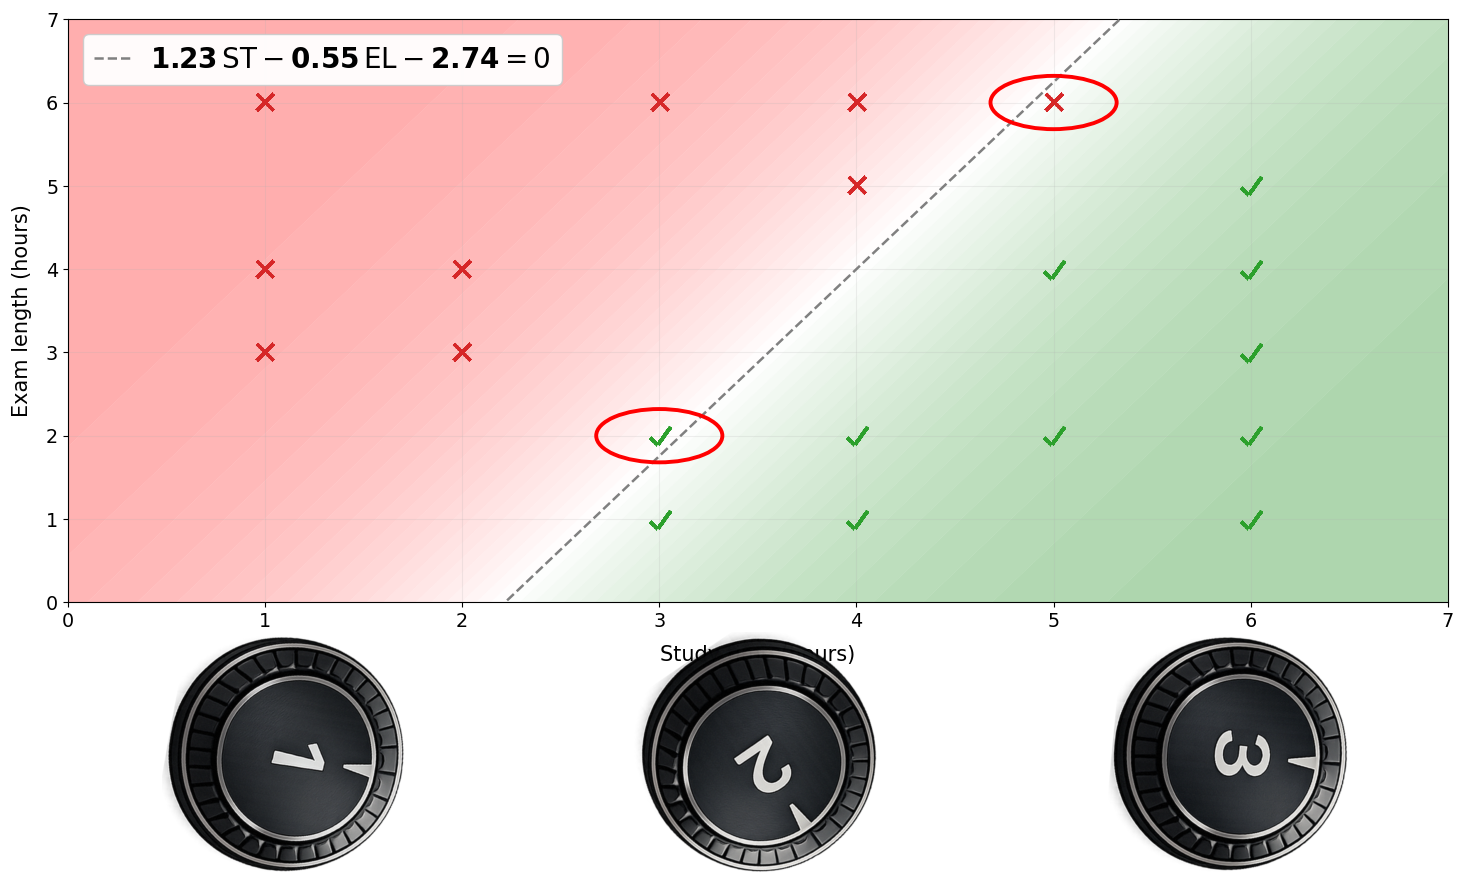

In [30]:
# (10) rotate boundary about **(4, 4)** (``emphasize="all"`` → all three knobs grown)
_PX44, _PY44 = 4.0, 4.0
_ROT_R = 1.35
# Start at **ST − EL = 0** ⇔ ``(w₁,w₂) ∝ (1,-1)`` ⇔ ``θ = −π/4`` for ``(w₁,w₂)=r(cos θ,sin θ)``; one full turn.
_TH0 = -0.25 * np.pi
_TH1 = _TH0 + 2 * np.pi
_export_knobs_pair(
    75,
    "line_rotate_pivot_4_4",
    _frames_rotation_pivot123(
        _PX44, _PY44, _ROT_R, _TH0, _TH1, "all", n_move=56, highlight_eps=True, with_knobs=True, include_return=False
    ),
    _frames_rotation_pivot123(
        _PX44,
        _PY44,
        _ROT_R,
        _TH0,
        _TH1,
        "all",
        n_move=56,
        show_contour=False,
        highlight_eps=True,
        with_knobs=True,
        include_return=False,
    ),
)


In [139]:
# Grid stills + build animations (``ch2_76`` / ``ch2_77``)
_anim_export_frames = _fgb1
save_mp4(_anim_export_frames, "ch2_76_eps1_nudge_grid_build.mp4", duration=_gif_dur(_GRID123_BUILD_MS))
del _anim_export_frames
gc.collect()

_anim_export_frames = _fgbh
save_mp4(_anim_export_frames, "ch2_77_eps_half_nudge_grid_build.mp4", duration=_gif_dur(_GRID123_BUILD_MS))
del _anim_export_frames
gc.collect()


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2925, 1348) to (2928, 1360) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x147e18c20] Stream #0: not enough frames to estimate rate; consider increasing probesize
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (2925, 1348) to (2928, 1360) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x14b704530] Stream #0: not enough frames to estimate rate; consider increasing probesize


0

## Late story — mistakes, sensitivity, calibration 

**Severity (one mistake, different σ)**
- **`ch2_78_one_mistake_uncertain_vs_confident.png`**: side-by-side still.

In [140]:
_PAIR_UNCERTAIN = (0.8, -1.55, 3.05)
_PAIR_CONFIDENT = (1.2875 * 3, -1.835 *3, 4.0*3)

def _fig_ch2_26():
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(EXPORT_FIGSIZE[0] * 1.62, EXPORT_FIGSIZE[1]))
    draw_probability_panel(axL, *_PAIR_UNCERTAIN, legend_linear_equation_values(*_PAIR_UNCERTAIN), show_contour=True, highlight_eps=True)
    axL.text(0.02, 0.98, r"mistake near $\sigma \approx \frac{1}{2}$", transform=axL.transAxes, va="top", fontsize=NOTE_SIZE)
    draw_probability_panel(axR, *_PAIR_CONFIDENT, legend_linear_equation_values(*_PAIR_CONFIDENT), show_contour=True, highlight_eps=True)
    axR.text(0.02, 0.98, r"mistake with higher confidence", transform=axR.transAxes, va="top", fontsize=NOTE_SIZE)
    fig.subplots_adjust(wspace=0.18)
    return fig
save_fig(_fig_ch2_26(), "ch2_78_one_mistake_uncertain_vs_confident.png")

## Keras logistic gradient descent (Chapter 1 export 79 analogue) — **`ch2_35`** / **`ch2_36`**

**Prerequisites:** Cell 1 (setup: **`ST`** / **`EL`**, **`ST_3D`** / **`EL_3D`**, **`CMAP_GD`**, **`draw_dataset`**, **`boundary_line_xy`**, **`SIG3D_ADJ`**, **`EXPORT_FIGSIZE`**, …).

- **`ch2_81_keras_logistic_gradient_descent_plane.mp4`** — Same training recipe as **`logistic-regression-chap1.ipynb`** Scene 8d **`79_logistic_gradient_descent_plane.gif`**: **`tensorflow.keras`** **`Sequential`**, **`Dense(1, input_dim=2, activation="sigmoid")`**, **`binary_crossentropy`**, **Adam** (`learning_rate=1e-1`); **`study_sep`**, **`exam_sep`**, **`y_sep`**; fit in **1-epoch chunks** for **40** epochs; **`predict`** on the fine **`ST`/`EL`** mesh for **`contourf`** + **`draw_dataset`**; **duplicate frames** + **tail hold** like export 79.
- **`ch2_82_keras_logistic_gradient_descent_sigmoid_3d.mp4`** — **Same model each frame**, **3D** **`plot_surface`** of σ over **`ST_3D`/`EL_3D`** (camera **elev 32°**, **azim −152°**); scatters at each student’s σ; **z = 0.5** decision segment in the box when defined.

**Workflow:** Run the **training** cell (re-seeds and retrains), then each **save** cell exports one GIF.

- **`ch2_79_keras_logistic_gradient_descent_plane_nocmap.mp4`** — same frames **without** σ **`contourf`**, **with** dashed **decision-boundary** line + numeric legend (like **`ch2_81`**).
- **`ch2_80_keras_logistic_gradient_descent_plane_knobs.mp4`** / **`…_knobs_nocmap.mp4`** — same with **PIL three-knob** bottom row (rotation ∝ weight vs initial epoch; **all three** dials **×1.25**); boundary + legend as **`ch2_79`**/**`81`**.
- **`ch2_83_keras_gd_from_half_mistakes_knobs.mp4`** / **`…_knobs_nocmap.mp4`** — **Adam** (same LR); init **`(w₁,w₂,b)=(0.5,-1,1)`**; knob refs **`(1,-1,1)`**; **full-batch**; **one** snapshot at **initialization** (before any training), then **200** single-epoch steps with **one** snapshot **after** each step (**201** frames before tail hold); raster matches curriculum knob MP4s (**`_GIF123_DPI`** / **`_panel123_img`**); **σ** **`contourf`** vs **boundary + scatter** only; **red mistake circles** every frame; tail hold.


In [40]:
# Keras single-layer logistic (2 → 1, sigmoid) + binary CE — train once, fill frame lists for ch2_35 / ch2_36.
# Same loop as chap1 Scene 8d export 79: 1-epoch chunks, snap after each chunk; separable roster only.

import tensorflow as tf
from tensorflow import keras

tf.random.set_seed(42)

GD_MS = 40
GD_HOLD_LAST = 18

_xa, _xb = float(xlim[0]), float(xlim[1])
_ya, _yb = float(ylim[0]), float(ylim[1])

mesh_plane = np.c_[ST.ravel(), EL.ravel()].astype(np.float32)
shape_plane = ST.shape
mesh_surf = np.c_[ST_3D.ravel(), EL_3D.ravel()].astype(np.float32)
shape_surf = ST_3D.shape

X_k = np.column_stack([study_sep.astype(np.float32), exam_sep.astype(np.float32)])
Y_k = y_sep.reshape(-1, 1).astype(np.float32)


def _keras_wb(model):
    W, b = model.layers[0].get_weights()
    return float(W[0, 0]), float(W[1, 0]), float(b[0])


def ch2_keras_gd_pack_frames(frames):
    out = []
    for im in frames:
        out.append(im.copy())
        out.append(im.copy())
    last = frames[-1].copy()
    for _ in range(GD_HOLD_LAST):
        out.append(last.copy())
    return out


def _snap_keras_plane(model, *, with_contour=True, with_knobs=False, prev=None, knob_angle_refs=None, emphasize="all", circle_mistakes=False):
    if with_knobs:
        fig, ax, axes_k = _ch2_figure_main_and_knob_axes()
    else:
        fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    w_st, w_el, bb = _keras_wb(model)
    if with_contour:
        Z = model.predict(mesh_plane, verbose=0).reshape(shape_plane)
        _ch2_sigma_contourf(ax, ST, EL, Z, zorder=1)
    leg = legend_linear_equation_values(w_st, w_el, bb)
    bxy = boundary_line_xy(w_st, w_el, bb, _xa, _xb, _ya, _yb)
    if bxy is not None:
        bx, by = bxy
        ax.plot(
            bx,
            by,
            c="grey",
            linestyle="--",
            linewidth=1.8,
            label=leg,
            zorder=3,
        )
    draw_dataset(ax, study_sep, exam_sep, y_sep)
    if circle_mistakes:
        highlight_mistakes(ax, study_sep, exam_sep, y_sep, w_st, w_el, bb)
    ax.set_xlim(_xa, _xb)
    ax.set_ylim(_ya, _yb)
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left", prop={"size": LEGEND_SIZE})
    if with_knobs:
        knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
        _ch2_draw_pil_knob_row(
            w_st, w_el, bb, prev, emphasize, fig, axes_k, knob_rgbs, canvas_sides, knob_angle_refs=knob_angle_refs
        )
    # Match ``_panel123_img`` / curriculum knob MP4 pixel size (``_GIF123_DPI``).
    dpi_k = min(int(_GIF123_DPI), 110) if with_knobs else int(_GIF123_DPI)
    return fig_to_image(fig, dpi=dpi_k, tight_layout=False)


def _snap_keras_sigmoid_3d(model):
    w_st, w_el, bb = _keras_wb(model)
    Zs = model.predict(mesh_surf, verbose=0).reshape(shape_surf)
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_subplot(111, projection="3d")
    fig.subplots_adjust(**SIG3D_ADJ)
    ax.plot_surface(
        ST_3D,
        EL_3D,
        Zs,
        cmap=CMAP_GD,
        vmin=0,
        vmax=1,
        alpha=0.42,
        linewidth=0,
        antialiased=True,
        shade=False,
    )
    zs_pts = model.predict(X_k, verbose=0).ravel()
    for i in range(n_sep):
        c = PASS_COLOR if y_sep[i] else FAIL_COLOR
        ax.scatter([study_sep[i]], [exam_sep[i]], [zs_pts[i]], color=c, s=55, depthshade=True, zorder=6)
    bxy = boundary_line_xy(w_st, w_el, bb, _xa, _xb, _ya, _yb)
    if bxy is not None:
        bx, by = bxy
        ax.plot(bx, by, np.full_like(bx, 0.5), "k--", linewidth=1.4, zorder=4)
    ax.view_init(elev=32.0, azim=-152.0)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_zlim(0, 1)
    ax.set_xlabel("Study time (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_ylabel("Exam length (hours)", fontsize=AXIS_LABEL_SIZE, labelpad=11)
    ax.set_zlabel(r"$\sigma(\mathrm{logit})$", fontsize=AXIS_LABEL_SIZE, labelpad=8)
    ax.tick_params(axis="both", which="major", labelsize=FONT_SIZE - 1)
    return fig_to_image(fig)


model_keras_gd = keras.models.Sequential()
model_keras_gd.add(keras.layers.Dense(1, input_dim=2, activation="sigmoid"))
model_keras_gd.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-1),
)

CH2_KERAS_GD_SNAPS_2D = []
CH2_KERAS_GD_SNAPS_2D_NC = []
CH2_KERAS_GD_SNAPS_2D_KNOB = []
CH2_KERAS_GD_SNAPS_2D_KNOB_NC = []
CH2_KERAS_GD_SNAPS_3D = []
_epochs, _sf = 100, 1
_prevk = None
_keras_knob_angle_ref = tuple(float(x) for x in _keras_wb(model_keras_gd))
for _ in range(_epochs // _sf):
    model_keras_gd.fit(X_k, Y_k, epochs=_sf, verbose=0, batch_size=100)
    CH2_KERAS_GD_SNAPS_2D.append(_snap_keras_plane(model_keras_gd))
    CH2_KERAS_GD_SNAPS_2D_NC.append(_snap_keras_plane(model_keras_gd, with_contour=False))
    CH2_KERAS_GD_SNAPS_2D_KNOB.append(_snap_keras_plane(model_keras_gd, with_knobs=True, prev=_prevk, knob_angle_refs=_keras_knob_angle_ref))
    CH2_KERAS_GD_SNAPS_2D_KNOB_NC.append(
        _snap_keras_plane(model_keras_gd, with_contour=False, with_knobs=True, prev=_prevk, knob_angle_refs=_keras_knob_angle_ref)
    )
    _prevk = _keras_wb(model_keras_gd)
    CH2_KERAS_GD_SNAPS_3D.append(_snap_keras_sigmoid_3d(model_keras_gd))


def _keras_half_pack_frames(frames, hold_last=GD_HOLD_LAST):
    # One frame per step + tail hold (no per-step duplication unlike ``ch2_keras_gd_pack_frames``).
    out = [im.copy() for im in frames]
    last = frames[-1].copy()
    for _ in range(hold_last):
        out.append(last.copy())
    return out


# --- **ch2_83**: GD from ``(w₁,w₂,b)=(0.5,-1,1)``; dial refs ``(1,-1,1)``; **init** snap + **200** epochs with **one** snap after **each** epoch (mistake circles every frame); tail hold on last; ``_snap_keras_plane`` uses ``_GIF123_DPI`` like ``_panel123_img`` ---
model_keras_gd_half = keras.models.Sequential()
model_keras_gd_half.add(keras.layers.Dense(1, input_dim=2, activation="sigmoid"))
model_keras_gd_half.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-1),
)
model_keras_gd_half.layers[0].set_weights(
    [
        np.array([[0.5], [-1.0]], dtype=np.float32),
        np.array([1.0], dtype=np.float32),
    ]
)

CH2_KERAS_HALF_KNOB_MISTAKES = []
CH2_KERAS_HALF_KNOB_MISTAKES_NC = []
_kref_half = (1.0, -1.0, 1.0)
_n_epochs_half = 200  # snapshots **after** each ``fit`` (plus **init** snapshots below)
_bs_half = int(X_k.shape[0])

_w_before = tuple(float(x) for x in _keras_wb(model_keras_gd_half))

CH2_KERAS_HALF_KNOB_MISTAKES.append(
    _snap_keras_plane(
        model_keras_gd_half,
        with_contour=True,
        with_knobs=True,
        prev=None,
        knob_angle_refs=_kref_half,
        emphasize=None,
        circle_mistakes=True,
    )
)
CH2_KERAS_HALF_KNOB_MISTAKES_NC.append(
    _snap_keras_plane(
        model_keras_gd_half,
        with_contour=False,
        with_knobs=True,
        prev=None,
        knob_angle_refs=_kref_half,
        emphasize=None,
        circle_mistakes=True,
    )
)

for _ep in range(_n_epochs_half):
    model_keras_gd_half.fit(X_k, Y_k, epochs=1, verbose=0, batch_size=_bs_half)
    CH2_KERAS_HALF_KNOB_MISTAKES.append(
        _snap_keras_plane(
            model_keras_gd_half,
            with_contour=True,
            with_knobs=True,
            prev=_w_before,
            knob_angle_refs=_kref_half,
            emphasize=None,
            circle_mistakes=True,
        )
    )
    CH2_KERAS_HALF_KNOB_MISTAKES_NC.append(
        _snap_keras_plane(
            model_keras_gd_half,
            with_contour=False,
            with_knobs=True,
            prev=_w_before,
            knob_angle_refs=_kref_half,
            emphasize=None,
            circle_mistakes=True,
        )
    )
    _w_before = tuple(float(x) for x in _keras_wb(model_keras_gd_half))

CH2_KERAS_GD_MS = GD_MS


In [42]:
# **ch2_83** — Keras GD from ``(0.5,-1,1)`` with mistake circles each step (see training cell).
_anim_export_frames = _keras_half_pack_frames(CH2_KERAS_HALF_KNOB_MISTAKES)
save_mp4(_anim_export_frames, "ch2_83_keras_gd_from_half_mistakes_knobs.mp4", duration=CH2_KERAS_GD_MS)
del _anim_export_frames
# _anim_export_frames = _keras_half_pack_frames(CH2_KERAS_HALF_KNOB_MISTAKES_NC)
# save_mp4(_anim_export_frames, "ch2_83_keras_gd_from_half_mistakes_knobs_nocmap.mp4", duration=CH2_KERAS_GD_MS)
# del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [142]:
# --- **ch2_52** — σ plane via ``draw_probability_panel``; colormap alpha fades to **0**.
# --- **ch2_53** — study–exam scatter + dashed **ST-EL=0** (``midpoint_shift``); σ ``contourf`` alpha fades to **0**.
_ms52 = _gif_dur(36)


In [143]:
_anim_export_frames = _frames_sigma_plane_colormap_fade(
        W_ST0,
        W_EL0,
        B0,
        legend_linear_equation_values(W_ST0, W_EL0, B0, difference_form=True),
        st_grid=ST_A,
        el_grid=EL_A,
    )
save_mp4(_anim_export_frames, "ch2_83_dataset_st_el_sigma_colormap_fade.mp4", duration=_ms52)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x1447188e0] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [144]:
_anim_export_frames = _frames_dataset_st_el_sigma_colormap_fade(
    W_ST0,
    W_EL0,
    B0,
    line_label="ST-EL=0",
    line_shift=None,
    highlight_eps=False,
)
save_mp4(_anim_export_frames, "ch2_84_dataset_st_el_plane_sigma_colormap_fade.mp4", duration=_ms52)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x157e19030] Stream #0: not enough frames to estimate rate; consider increasing probesize


In [145]:
del _ms52


In [146]:
_anim_export_frames = ch2_keras_gd_pack_frames(CH2_KERAS_GD_SNAPS_2D_NC)
save_mp4(_anim_export_frames, "ch2_79_keras_logistic_gradient_descent_plane_nocmap.mp4", duration=CH2_KERAS_GD_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [147]:
_anim_export_frames = ch2_keras_gd_pack_frames(CH2_KERAS_GD_SNAPS_2D_KNOB)
save_mp4(_anim_export_frames, "ch2_80_keras_logistic_gradient_descent_plane_knobs.mp4", duration=CH2_KERAS_GD_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [148]:
_anim_export_frames = ch2_keras_gd_pack_frames(CH2_KERAS_GD_SNAPS_2D_KNOB_NC)
save_mp4(_anim_export_frames, "ch2_80_keras_logistic_gradient_descent_plane_knobs_nocmap.mp4", duration=CH2_KERAS_GD_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1650, 1045) to (1664, 1056) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [149]:
_anim_export_frames = ch2_keras_gd_pack_frames(CH2_KERAS_GD_SNAPS_2D)
save_mp4(_anim_export_frames, "ch2_81_keras_logistic_gradient_descent_plane.mp4", duration=CH2_KERAS_GD_MS)
del _anim_export_frames


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [150]:
save_mp4(
    ch2_keras_gd_pack_frames(CH2_KERAS_GD_SNAPS_3D),
    "ch2_82_keras_logistic_gradient_descent_sigmoid_3d.mp4",
    duration=CH2_KERAS_GD_MS,
)

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 1900) to (3008, 1904) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


## Knob intro **1**/**2** — **ST − EL = 0** line, legend **`1ST − 1EL = 0`**

Figure size stays **`EXPORT_FIGSIZE`** on every frame (same pixel footprint as dataset panels); the **main axes rect** morphs from the default single-panel box into the **top row** of the strip layout while **knobs 1–2** use tunable **figure-fraction** starts (defaults: probed legend **y**, **x** spaced), then fly to their **bottom slots**, **growing** every frame. Output: **`renders/ch2_85_intro12_st_el_line.mp4`**.


In [33]:
# --- MP4: knobs 1 & 2 start on legend **1** coeffs → bottom slots; constant EXPORT_FIGSIZE; axes morph to strip ---
from PIL import Image

for _p in (
    OUTPUT_DIR / "knob_1_cropped.png",
    OUTPUT_DIR / "knob_2_cropped.png",
    OUTPUT_DIR / "knob_3_cropped.png",
):
    if not _p.is_file():
        raise FileNotFoundError(_p)

_K12_K1 = Image.open(OUTPUT_DIR / "knob_1_cropped.png").convert("RGBA")
_K12_K2 = Image.open(OUTPUT_DIR / "knob_2_cropped.png").convert("RGBA")

_WS_STEL, _WE_STEL, _BB_STEL = 1.0, -1.0, 0.0

# --- Initial knob **figure** positions ``(x, y)`` in ``0–1`` fractions. ``None`` = auto (legend anchors only). ---
# Defaults below: same **y** as probed legend anchors at ``t=0``, **x** evenly spaced (Δ≈0.096 fig fraction ≈ 1.44 in on a 15.0 in-wide figure).
# Set to ``None`` to re-enable pure anchors; tweak literals to taste. Run this cell before **intro3**.
_KNOB_INTRO_START_W1 = (0.185, 0.84)
_KNOB_INTRO_START_W2 = (0.245, 0.84)
_KNOB_INTRO_START_B = (0.242, 0.91)

_CACHE_KNOB_LAYOUT = None


def _knob_strip_layout_rects():
    """Figure-**fraction** rects: data panel + three bottom knob slots (final layout)."""
    global _CACHE_KNOB_LAYOUT
    if _CACHE_KNOB_LAYOUT is not None:
        return _CACHE_KNOB_LAYOUT
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.34], hspace=0.14, wspace=0.08)
    axd = fig.add_subplot(gs[0, :])
    axk = [fig.add_subplot(gs[1, j]) for j in range(3)]
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06)
    fig.canvas.draw()
    dr = axd.get_position()
    data_r = (float(dr.x0), float(dr.y0), float(dr.width), float(dr.height))
    kr = []
    for a in axk:
        pr = a.get_position()
        kr.append((float(pr.x0), float(pr.y0), float(pr.width), float(pr.height)))
    plt.close(fig)
    _CACHE_KNOB_LAYOUT = (data_r, kr)
    return _CACHE_KNOB_LAYOUT


def _smoothstep(u):
    u = float(np.clip(u, 0.0, 1.0))
    return u * u * (3.0 - 2.0 * u)


def _lerp_rect(t, a, b):
    u = _smoothstep(t)
    return tuple(float(a[i] + u * (b[i] - a[i])) for i in range(4))


def _rect_center_wh(r):
    x0, y0, w, h = r
    return x0 + 0.5 * w, y0 + 0.5 * h, w, h


_CACHE_DEFAULT_AX_RECT = None


def _default_export_axes_rect():
    """Same axes box as ``plt.subplots(figsize=EXPORT_FIGSIZE)`` (matches chap1/chap2 panels)."""
    global _CACHE_DEFAULT_AX_RECT
    if _CACHE_DEFAULT_AX_RECT is not None:
        return _CACHE_DEFAULT_AX_RECT
    fig, ax = plt.subplots(figsize=EXPORT_FIGSIZE)
    fig.canvas.draw()
    pr = ax.get_position()
    _CACHE_DEFAULT_AX_RECT = (float(pr.x0), float(pr.y0), float(pr.width), float(pr.height))
    plt.close(fig)
    return _CACHE_DEFAULT_AX_RECT


def _knob_intro12_legend_anchor_centers_fig(fig, axd, renderer):
    """Figure (x, y): knob **1** on first coeff **1**; knob **2** centered on the EL term — from this frame's legend layout."""
    leg = axd.get_legend()
    if leg is None or not leg.get_texts():
        return None
    txt = leg.get_texts()[0]
    fp = txt.get_fontproperties()

    def _em_w(ss):
        tt = fig.text(0, 0, ss, visible=False, fontproperties=fp)
        fig.canvas.draw()
        w = float(tt.get_window_extent(renderer=renderer).width)
        tt.remove()
        return w

    bb = txt.get_window_extent(renderer=renderer)
    off1 = 0.5 * _em_w(r"$1\,$")
    off_el = _em_w(r"$1\,\mathrm{ST} - 1\,$")
    w_el = _em_w(r"$\mathrm{EL}$")
    off2 = off_el + 0.5 * w_el
    inv = fig.transFigure.inverted()
    y_disp = float(bb.y0 + 0.5 * bb.height)
    p1 = inv.transform((bb.x0 + off1, y_disp))
    p2 = inv.transform((bb.x0 + off2, y_disp))
    return (float(p1[0]), float(p1[1])), (float(p2[0]), float(p2[1]))


def _frame_knob_intro12(t):
    """t ∈ [0, 1]: grow layout + fly knobs 1 and 2; knob 3 stays hidden."""
    t = float(np.clip(t, 0.0, 1.0))
    u = _smoothstep(t)
    data_end, knobs_end = _knob_strip_layout_rects()
    data_r = _lerp_rect(t, _default_export_axes_rect(), data_end)

    fw, fh = float(EXPORT_FIGSIZE[0]), float(EXPORT_FIGSIZE[1])
    fig = plt.figure(figsize=(fw, fh))

    axd = fig.add_axes(data_r)
    leg12 = r"$1\,\mathrm{ST} - 1\,\mathrm{EL} = 0$"
    draw_probability_panel(
        axd,
        _WS_STEL,
        _WE_STEL,
        _BB_STEL,
        leg12,
        show_contour=False,
        highlight_eps=True,
        st_grid=ST_A,
        el_grid=EL_A,
    )

    # Knob **1** on the first **1**; knob **2** on **EL**; then fly to bottom slots.
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg = axd.get_legend()
    if leg is None or not leg.get_texts():
        ddx, ddy, ddw, ddh = data_r
        s1c = (ddx + 0.08 * ddw, ddy + 0.88 * ddh)
        s2c = (ddx + 0.30 * ddw, ddy + 0.88 * ddh)
    else:
        anc = _knob_intro12_legend_anchor_centers_fig(fig, axd, renderer)
        if anc is None:
            ddx, ddy, ddw, ddh = data_r
            s1c = (ddx + 0.08 * ddw, ddy + 0.88 * ddh)
            s2c = (ddx + 0.30 * ddw, ddy + 0.88 * ddh)
        else:
            s1c, s2c = anc
    _auto_w1 = (float(s1c[0]), float(s1c[1]))
    _auto_w2 = (float(s2c[0]), float(s2c[1]))
    s1c = _KNOB_INTRO_START_W1 if _KNOB_INTRO_START_W1 is not None else _auto_w1
    s2c = _KNOB_INTRO_START_W2 if _KNOB_INTRO_START_W2 is not None else _auto_w2
    tiny = max(0.006, 0.02 * (1.0 - u) + 0.001)
    ends = knobs_end[0], knobs_end[1]
    for img, sc, end_r in ((_K12_K1, s1c, ends[0]), (_K12_K2, s2c, ends[1])):
        ex, ey, ew, eh = _rect_center_wh(end_r)
        sx, sy = sc
        cx = sx + u * (ex - sx)
        cy = sy + u * (ey - sy)
        side_max = float(min(ew, eh))
        side = float(tiny + u * (side_max - tiny))
        axk = fig.add_axes([cx - 0.5 * side, cy - 0.5 * side, side, side])
        axk.imshow(np.asarray(img))
        axk.axis("off")

    return fig_to_image(fig, dpi=min(int(EXPORT_DPI), 100))


In [ ]:
_n12 = max(36, _smooth_n(28))
_ts12 = np.linspace(0.0, 1.0, _n12)
_frames12 = [_frame_knob_intro12(float(t)) for t in _ts12]
_MS12 = _gif_dur(34)
save_mp4(_frames12, "ch2_85_intro12_st_el_line.mp4", duration=_MS12)
del _frames12
gc.collect()

## **`ch2_98`** — Pivot stop (**`ch2_75`** end): nocmap → σ colormap fade-in (**three knobs**)

Hold on the **same** boundary weights as the **last** frame of **`ch2_75`** (`include_return=False`), **PIL three-knob** strip and dial refs like that clip (`emphasize="all"`, pivot-θ knob refs), **without** σ `contourf`, then ramp **`contourf`** alpha **0 →** `_CH2_SIGMA_CONTOUR_ALPHA`. Output: **`renders/ch2_98_ch75_end_sigma_cmap_fade_in.mp4`**.

In [ ]:
# --- **ch2_98** — hold nocmap (``ch2_75`` end weights) → ramp σ ``contourf`` alpha; **three-knob** strip (``_panel123_img``) ---
import gc

_WS98, _WE98, _BB98 = _weights_line_through_pivot(_PX44, _PY44, float(_TH1), _ROT_R)
_ws0p, _we0p, _bb0p = _weights_line_through_pivot(_PX44, _PY44, float(_TH0), _ROT_R)
_kref98 = (float(_ws0p), float(_we0p), float(_bb0p))
_prev98 = (float(_WS98), float(_WE98), float(_BB98))

_hold98 = max(6, _smooth_n(4))
_fade98 = max(22, _smooth_n(14))
_hold98b = max(6, _smooth_n(4))
_a_full = float(_CH2_SIGMA_CONTOUR_ALPHA)

_frames98 = []
for _ in range(_hold98):
    _frames98.append(
        _panel123_img(
            _WS98,
            _WE98,
            _BB98,
            "all",
            show_contour=False,
            with_knobs=True,
            prev=_prev98,
            highlight_eps=True,
            knob_angle_refs=_kref98,
        )
    )

for k in range(_fade98):
    u = float(k) / float(max(_fade98 - 1, 1))
    a = _a_full * u
    _frames98.append(
        _panel123_img(
            _WS98,
            _WE98,
            _BB98,
            "all",
            show_contour=True,
            with_knobs=True,
            prev=_prev98,
            highlight_eps=True,
            knob_angle_refs=_kref98,
            contour_alpha=a,
        )
    )

for _ in range(_hold98b):
    _frames98.append(
        _panel123_img(
            _WS98,
            _WE98,
            _BB98,
            "all",
            show_contour=True,
            with_knobs=True,
            prev=_prev98,
            highlight_eps=True,
            knob_angle_refs=_kref98,
            contour_alpha=_a_full,
        )
    )

_MS98 = _gif_dur(34)
save_mp4(_frames98, "ch2_98_ch75_end_sigma_cmap_fade_in.mp4", duration=_MS98)
del _frames98
gc.collect()


## **`ch2_99`** — Reverse **`ch2_85`** intro12 with σ colormap + three knobs

From **`ch2_75`** terminal weights: **t = 0** matches the **strip** layout with knobs **in slots** and full σ field; motion reverses **`ch2_85_intro12_st_el_line`**. Knobs **1–2** use **`_KNOB_INTRO_START_W1` / `_KNOB_INTRO_START_W2`**; knob **3** start is **2×knob2 − knob1** (same spacing as **1→2**). Output: **`renders/ch2_99_ch75_end_intro12_reverse_three_knobs_cmap.mp4`**.

In [39]:
# --- **ch2_99** — reverse intro12 layout + fly **three** knobs up; σ colormap on; **ch2_75** end weights ---
_WS99_END, _WE99_END, _BB99_END = _weights_line_through_pivot(_PX44, _PY44, float(_TH1), _ROT_R)
import gc
from PIL import Image

if not (OUTPUT_DIR / "knob_3_cropped.png").is_file():
    raise FileNotFoundError(OUTPUT_DIR / "knob_3_cropped.png")

_K99_K1 = _K12_K1
_K99_K2 = _K12_K2
_K99_K3 = Image.open(OUTPUT_DIR / "knob_3_cropped.png").convert("RGBA")


def _frame_ch2_99_knob_outro12_rev(t):
    """t ∈ [0, 1]: strip + seated knobs → default axes + knobs at legend (reverse of ``_frame_knob_intro12``)."""
    t = float(np.clip(t, 0.0, 1.0))
    u = _smoothstep(1.0 - t)
    data_end, knobs_end = _knob_strip_layout_rects()
    data_r = _lerp_rect(t, data_end, _default_export_axes_rect())

    fw, fh = float(EXPORT_FIGSIZE[0]), float(EXPORT_FIGSIZE[1])
    fig = plt.figure(figsize=(fw, fh))

    axd = fig.add_axes(data_r)
    leg99 = legend_linear_equation_values_bold_param(_WS99_END, _WE99_END, _BB99_END, "all")
    draw_probability_panel(
        axd,
        _WS99_END,
        _WE99_END,
        _BB99_END,
        leg99,
        show_contour=True,
        highlight_eps=True,
        st_grid=ST_A,
        el_grid=EL_A,
        contour_alpha=float(_CH2_SIGMA_CONTOUR_ALPHA),
    )

    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg = axd.get_legend()
    if leg is None or not leg.get_texts():
        ddx, ddy, ddw, ddh = data_r
        s1c = (ddx + 0.08 * ddw, ddy + 0.88 * ddh)
        s2c = (ddx + 0.30 * ddw, ddy + 0.88 * ddh)
    else:
        anc = _knob_intro12_legend_anchor_centers_fig(fig, axd, renderer)
        if anc is None:
            ddx, ddy, ddw, ddh = data_r
            s1c = (ddx + 0.08 * ddw, ddy + 0.88 * ddh)
            s2c = (ddx + 0.30 * ddw, ddy + 0.88 * ddh)
        else:
            s1c, s2c = anc
    _auto_w1 = (float(s1c[0]), float(s1c[1]))
    _auto_w2 = (float(s2c[0]), float(s2c[1]))
    s1c = _KNOB_INTRO_START_W1 if _KNOB_INTRO_START_W1 is not None else _auto_w1
    s2c = _KNOB_INTRO_START_W2 if _KNOB_INTRO_START_W2 is not None else _auto_w2
    s3c = (2.0 * s2c[0] - s1c[0], 2.0 * s2c[1] - s1c[1])

    tiny = max(0.006, 0.02 * (1.0 - u) + 0.001)
    ends = knobs_end[0], knobs_end[1], knobs_end[2]
    e1x, e1y, e1w, e1h = _rect_center_wh(ends[0])
    e2x, e2y, e2w, e2h = _rect_center_wh(ends[1])
    _, _, e3w, e3h = _rect_center_wh(ends[2])
    e3x = e2x + (e2x - e1x)
    e3y = e2y + (e2y - e1y)  # slot spacing |3−2| = |2−1| (vs raw ``ends[2]`` center)

    for _ki, (img, sc, end_r) in enumerate(
        (
            (_K99_K1, s1c, ends[0]),
            (_K99_K2, s2c, ends[1]),
            (_K99_K3, s3c, ends[2]),
        )
    ):
        if _ki == 2:
            ex, ey, ew, eh = e3x, e3y, e3w, e3h
        else:
            ex, ey, ew, eh = _rect_center_wh(end_r)
        sx, sy = sc
        cx = sx + u * (ex - sx)
        cy = sy + u * (ey - sy)
        side_max = float(min(ew, eh))
        side = float(tiny + u * (side_max - tiny))
        axk = fig.add_axes([cx - 0.5 * side, cy - 0.5 * side, side, side])
        axk.imshow(np.asarray(img))
        axk.axis("off")

    return fig_to_image(fig, dpi=min(int(EXPORT_DPI), 100))


_n99 = max(36, _smooth_n(28))
_ts99 = np.linspace(0.0, 1.0, _n99)
_frames99 = [_frame_ch2_99_knob_outro12_rev(float(t)) for t in _ts99]
_MS99 = _gif_dur(34)
save_mp4(_frames99, "ch2_99_ch75_end_intro12_reverse_three_knobs_cmap.mp4", duration=_MS99)
del _frames99
gc.collect()


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x12b9042e0] Stream #0: not enough frames to estimate rate; consider increasing probesize


6996

## Knob intro **3** — legend **`1ST − 1EL + 0 = 0`**, knobs **1**/**2** parked

Same **`EXPORT_FIGSIZE`** on every frame as dataset exports; **knobs 1 and 2** are already seated; **knob 3** grows from the tunable **bias start** (same default row as knobs **1–2**, spaced in **x**), then **settles** into the **third** slot. Output: **`renders/ch2_86_intro3_bias_slot.mp4`**.


In [155]:
# --- MP4: third knob grows into place (layout already final) ---
from PIL import Image

_K3_K1 = Image.open(OUTPUT_DIR / "knob_1_cropped.png").convert("RGBA")
_K3_K2 = Image.open(OUTPUT_DIR / "knob_2_cropped.png").convert("RGBA")
_K3_K3 = Image.open(OUTPUT_DIR / "knob_3_cropped.png").convert("RGBA")

_CACHE_K3_BIAS_S3C = None  # invalidate after edits to bias anchor

_WS3, _WE3, _BB3 = 1.0, -1.0, 0.0


def _smoothstep3(u):
    u = float(np.clip(u, 0.0, 1.0))
    return u * u * (3.0 - 2.0 * u)


def _rect_center_wh3(r):
    x0, y0, w, h = r
    return x0 + 0.5 * w, y0 + 0.5 * h, w, h


_CACHE_KNOB_LAYOUT3 = None


def _knob_strip_layout_rects3():
    global _CACHE_KNOB_LAYOUT3
    if _CACHE_KNOB_LAYOUT3 is not None:
        return _CACHE_KNOB_LAYOUT3
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    gs = fig.add_gridspec(2, 3, height_ratios=[1.0, 0.34], hspace=0.14, wspace=0.08)
    axd = fig.add_subplot(gs[0, :])
    axk = [fig.add_subplot(gs[1, j]) for j in range(3)]
    fig.subplots_adjust(left=0.06, right=0.98, top=0.94, bottom=0.06)
    fig.canvas.draw()
    dr = axd.get_position()
    data_r = (float(dr.x0), float(dr.y0), float(dr.width), float(dr.height))
    kr = []
    for a in axk:
        pr = a.get_position()
        kr.append((float(pr.x0), float(pr.y0), float(pr.width), float(pr.height)))
    plt.close(fig)
    return data_r, kr


_CACHE_K3_BIAS_S3C = None


def _knob_intro3_bias_start_center_fig():
    """Figure coords for knob **3** start: bias ``0`` in ``...+ 0 = 0`` (biased right of digit center)."""
    global _CACHE_K3_BIAS_S3C
    if _CACHE_K3_BIAS_S3C is not None:
        return _CACHE_K3_BIAS_S3C
    data_probe, _kr = _knob_strip_layout_rects3()
    fig = plt.figure(figsize=EXPORT_FIGSIZE)
    ax = fig.add_axes(data_probe)
    _leg_bias0 = r"$1\,\mathrm{ST} - 1\,\mathrm{EL} + 0 = 0$"
    draw_probability_panel(
        ax,
        _WS3,
        _WE3,
        _BB3,
        _leg_bias0,
        show_contour=False,
        highlight_eps=True,
        st_grid=ST_A,
        el_grid=EL_A,
    )
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()
    leg = ax.get_legend()
    if leg is None or not leg.get_texts():
        ddx, ddy, ddw, ddh = data_probe
        _CACHE_K3_BIAS_S3C = (float(ddx + 0.68 * ddw), float(ddy + 0.78 * ddh))
        plt.close(fig)
        return _CACHE_K3_BIAS_S3C
    txt = leg.get_texts()[0]
    fp = txt.get_fontproperties()

    def _dp_w3(s):
        tt = fig.text(0, 0, s, visible=False, fontproperties=fp)
        fig.canvas.draw()
        w = float(tt.get_window_extent(renderer=renderer).width)
        tt.remove()
        return w

    bb_d = txt.get_window_extent(renderer=renderer)
    W = float(max(bb_d.width, 1e-9))
    w_bias0 = _dp_w3(r"$0$")
    off = _dp_w3(r"$1\,\mathrm{ST} - 1\,\mathrm{EL} +\, $") + 0.5 * w_bias0
    fr = off / W
    bb_f = bb_d.transformed(fig.transFigure.inverted())
    cx = float(bb_f.x0 + fr * bb_f.width)
    cy = float(bb_f.y0 + 0.5 * bb_f.height)
    _CACHE_K3_BIAS_S3C = (cx, cy)
    plt.close(fig)
    return _CACHE_K3_BIAS_S3C


def _frame_knob_intro3(t):
    t = float(np.clip(t, 0.0, 1.0))
    u = _smoothstep3(t)
    data_r, knobs_end = _knob_strip_layout_rects3()
    fw, fh = float(EXPORT_FIGSIZE[0]), float(EXPORT_FIGSIZE[1])
    fig = plt.figure(figsize=(fw, fh))
    axd = fig.add_axes(data_r)
    if u > 0.88:
        leg3 = legend_linear_equation_values_bold_param(_WS3, _WE3, _BB3, "b")
    else:
        leg3 = r"$1\,\mathrm{ST} - 1\,\mathrm{EL} + 0 = 0$"
    draw_probability_panel(
        axd,
        _WS3,
        _WE3,
        _BB3,
        leg3,
        show_contour=False,
        highlight_eps=True,
        st_grid=ST_A,
        el_grid=EL_A,
    )

    for img, end_r in ((_K3_K1, knobs_end[0]), (_K3_K2, knobs_end[1])):
        x0, y0, w, h = end_r
        axk = fig.add_axes([x0, y0, w, h])
        axk.imshow(np.asarray(img))
        axk.axis("off")

    ex, ey, ew, eh = _rect_center_wh3(knobs_end[2])
    sx, sy = _knob_intro3_bias_start_center_fig()
    _auto_b = (float(sx), float(sy))
    sx, sy = _KNOB_INTRO_START_B if _KNOB_INTRO_START_B is not None else _auto_b
    cx = sx + u * (ex - sx)
    cy = sy + u * (ey - sy)
    tiny = 0.012
    side_max = float(min(ew, eh))
    side = float(tiny + u * (side_max - tiny))
    ax3 = fig.add_axes([cx - 0.5 * side, cy - 0.5 * side, side, side])
    ax3.imshow(np.asarray(_K3_K3))
    ax3.axis("off")

    return fig_to_image(fig, dpi=min(int(EXPORT_DPI), 100))


_n3 = max(32, _smooth_n(24))
_ts3 = np.linspace(0.0, 1.0, _n3)
_frames3 = [_frame_knob_intro3(float(t)) for t in _ts3]
_MS3 = _gif_dur(34)
save_mp4(_frames3, "ch2_86_intro3_bias_slot.mp4", duration=_MS3)
del _frames3
gc.collect()


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (1500, 950) to (1504, 960) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
[rawvideo @ 0x143704940] Stream #0: not enough frames to estimate rate; consider increasing probesize


33534818

## Follow-ups after **ch2_85** / **ch2_86**

Run **in order**: **config** → **defs** → **export**. Knob clips: **w₁** / **w₂** sweeps (two knobs, **85** layout); bias sweep (three knobs, **86** layout). **ch2_106** / **ch2_107**: shifted thresholds with **two** knobs + point labels; PNGs are **LANCZOS-resized to 1504×960** (same target as **imageio-ffmpeg** macro-block rounding on the 1500×950 raster) so both axes match **decoded** knob MP4 frames without a white bottom band.

Exports: **`ch2_100`–`ch2_107`** in **`renders/`** (see ``CH2_FOLLOW`` in the config cell).


In [171]:
# --- Post **ch2_85** / **ch2_86** follow-ups — **config only** (run before defs + export) ---
# Requires: setup, ``EXPORT_DPI``, ``_gif_dur``, ``_smooth_n``, ``_panel123_img`` (curriculum cell).

CH2_FOLLOW = {
    "hold_n": 6,
    "move_n": 22,
    "tail_n": 6,
    "phases_w1": [
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (0.0, -1.0, 0.0)),
        ("hold", (0.0, -1.0, 0.0)),
        ("ramp", (0.0, -1.0, 0.0), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (2.0, -1.0, 0.0)),
        ("hold", (2.0, -1.0, 0.0)),
        ("ramp", (2.0, -1.0, 0.0), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
    ],
    "phases_w2": [
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (1.0, -2.0, 0.0)),
        ("hold", (1.0, -2.0, 0.0)),
        ("ramp", (1.0, -2.0, 0.0), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (1.0, 0.0, 0.0)),
        ("hold", (1.0, 0.0, 0.0)),
        ("ramp", (1.0, 0.0, 0.0), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
    ],
    "bias_phases": [
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (1.0, -1.0, 2.5)),
        ("hold", (1.0, -1.0, 2.5)),
        ("ramp", (1.0, -1.0, 2.5), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
        ("ramp", (1.0, -1.0, 0.0), (1.0, -1.0, -2.5)),
        ("hold", (1.0, -1.0, -2.5)),
        ("ramp", (1.0, -1.0, -2.5), (1.0, -1.0, 0.0)),
        ("hold", (1.0, -1.0, 0.0)),
    ],
    "exports": [
        {"kind": "intro85", "phases": "phases_w1", "emphasize": "st", "contour": True, "file": "ch2_100_intro85_follow_w1_knob.mp4"},
        {"kind": "intro85", "phases": "phases_w1", "emphasize": "st", "contour": False, "file": "ch2_101_intro85_follow_w1_knob_nocmap.mp4"},
        {"kind": "intro85", "phases": "phases_w2", "emphasize": "el", "contour": True, "file": "ch2_102_intro85_follow_w2_knob.mp4"},
        {"kind": "intro85", "phases": "phases_w2", "emphasize": "el", "contour": False, "file": "ch2_103_intro85_follow_w2_knob_nocmap.mp4"},
        {"kind": "intro86_bias", "phases": "bias_phases", "contour": True, "file": "ch2_104_intro86_follow_bias_shift.mp4"},
        {"kind": "intro86_bias", "phases": "bias_phases", "contour": False, "file": "ch2_105_intro86_follow_bias_shift_nocmap.mp4"},
    ],
    "png_thresholds": [
        ((1.0, -1.0, -1.5), "ch2_106_dataset_threshold_st_el_minus_1p5.png"),
        ((1.0, -1.0, 1.5), "ch2_107_dataset_threshold_st_el_plus_1p5.png"),
    ],
}
CH2_FOLLOW["ms"] = _gif_dur(36)


In [172]:
# --- Post **ch2_85** / **ch2_86** — builders (run after **ch2_follow_post_intro_config**) ---
# Same **matplotlib** raster DPI as **ch2_85** / **ch2_86** (``_frame_knob_intro12`` / ``_frame_knob_intro3``).
CH2_KNOB_INTRO_FRAME_DPI = min(int(EXPORT_DPI), 100)


def ch2_follow_h264_knob_frame_pixel_size(*, dpi=None, mb=16):
    """Width/height **imageio-ffmpeg** targets for ``EXPORT_FIGSIZE`` (``macro_block_size=16`` rounding)."""
    d = int(CH2_KNOB_INTRO_FRAME_DPI if dpi is None else dpi)
    w0 = int(round(float(EXPORT_FIGSIZE[0]) * d))
    h0 = int(round(float(EXPORT_FIGSIZE[1]) * d))
    w = ((w0 + mb - 1) // mb) * mb
    h = ((h0 + mb - 1) // mb) * mb
    return w, h


def ch2_follow_resize_png_to_h264_knob_canvas(im, mb=16):
    """**Resize** (LANCZOS) to the H.264 knob-frame size — same as ffmpeg’s “resize to macro_block”, not a letterbox pad."""
    from PIL import Image as _PILImage
    tw, th = ch2_follow_h264_knob_frame_pixel_size(mb=mb)
    if im.size == (tw, th):
        return im
    return im.resize((tw, th), resample=_PILImage.Resampling.LANCZOS)


def ch2_follow_frame_intro85_pair(ws, we, bb, emphasize, *, show_contour=True, cfg=None):
    """Strip layout with **two** bottom knobs (end pose of **ch2_85**)."""
    cfg = cfg or CH2_FOLLOW
    data_end, knobs_end = _knob_strip_layout_rects()
    fw, fh = float(EXPORT_FIGSIZE[0]), float(EXPORT_FIGSIZE[1])
    fig = plt.figure(figsize=(fw, fh))
    axd = fig.add_axes(data_end)
    leg = legend_linear_equation_values_bold_param(ws, we, bb, emphasize)
    draw_probability_panel(
        axd,
        float(ws),
        float(we),
        float(bb),
        leg,
        show_contour=show_contour,
        highlight_eps=True,
        st_grid=ST_A,
        el_grid=EL_A,
    )
    knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
    ref = (1.0, -1.0, 0.0)
    rots = _knob_rot_deg_from_refs(float(ws), float(we), float(bb), ref)
    active = _knob_active_mask(emphasize)
    scales = tuple(float(_KNOB_ACTIVE_SCALE) if active[i] else 1.0 for i in range(3))
    for i in range(2):
        x0, y0, w, h = knobs_end[i]
        cx = x0 + 0.5 * w
        cy = y0 + 0.5 * h
        sc = float(np.clip(scales[i], 1.0, float(_KNOB_ACTIVE_SCALE)))
        sw = sc * w
        sh = sc * h
        axk = fig.add_axes([cx - 0.5 * sw, cy - 0.5 * sh, sw, sh])
        rd = float(rots[i])
        if abs(rd) > 1e-9:
            arr = np.asarray(_ch2_knob_pil_rotated_square(knob_rgbs[i], rd, canvas_sides[i]))
        else:
            arr = np.asarray(knob_rgbs[i])
        axk.imshow(arr, interpolation="bilinear")
        axk.axis("off")
    return fig_to_image(fig, dpi=CH2_KNOB_INTRO_FRAME_DPI)


def ch2_follow_compile_intro85(phases, emphasize, *, show_contour, cfg=None):
    cfg = cfg or CH2_FOLLOW
    nh, nm, nt = int(cfg["hold_n"]), int(cfg["move_n"]), int(cfg["tail_n"])
    out = []
    for ph in phases:
        tag = ph[0]
        if tag == "hold":
            ws, we, b = ph[1]
            for _ in range(_smooth_n(nh)):
                out.append(ch2_follow_frame_intro85_pair(ws, we, b, emphasize, show_contour=show_contour, cfg=cfg))
        elif tag == "ramp":
            (ws0, we0, b0), (ws1, we1, b1) = ph[1], ph[2]
            for u in np.linspace(0.0, 1.0, _smooth_n(nm)):
                ws = ws0 + u * (ws1 - ws0)
                we = we0 + u * (we1 - we0)
                bb = b0 + u * (b1 - b0)
                out.append(ch2_follow_frame_intro85_pair(ws, we, bb, emphasize, show_contour=show_contour, cfg=cfg))
            for _ in range(_smooth_n(nt)):
                out.append(ch2_follow_frame_intro85_pair(ws1, we1, b1, emphasize, show_contour=show_contour, cfg=cfg))
        else:
            raise ValueError(tag)
    return out


def ch2_follow_compile_intro86_bias(phases, *, show_contour, cfg=None):
    cfg = cfg or CH2_FOLLOW
    nh, nm, nt = int(cfg["hold_n"]), int(cfg["move_n"]), int(cfg["tail_n"])
    ws0, we0, b0 = 1.0, -1.0, 0.0
    out = []
    prev = None
    kref = (ws0, we0, b0)
    for ph in phases:
        tag = ph[0]
        if tag == "hold":
            ws, we, b = ph[1]
            for _ in range(_smooth_n(nh)):
                out.append(
                    _panel123_img(
                        ws,
                        we,
                        b,
                        "b",
                        show_contour=show_contour,
                        with_knobs=True,
                        prev=prev,
                        highlight_eps=True,
                        knob_angle_refs=kref,
                    )
                )
                prev = (float(ws), float(we), float(b))
        elif tag == "ramp":
            (ws0, we0, b0), (ws1, we1, b1) = ph[1], ph[2]
            for u in np.linspace(0.0, 1.0, _smooth_n(nm)):
                ws = ws0 + u * (ws1 - ws0)
                we = we0 + u * (we1 - we0)
                bb = b0 + u * (b1 - b0)
                out.append(
                    _panel123_img(
                        ws,
                        we,
                        bb,
                        "b",
                        show_contour=show_contour,
                        with_knobs=True,
                        prev=prev,
                        highlight_eps=True,
                        knob_angle_refs=kref,
                    )
                )
                prev = (float(ws), float(we), float(bb))
            for _ in range(_smooth_n(nt)):
                out.append(
                    _panel123_img(
                        ws1,
                        we1,
                        b1,
                        "b",
                        show_contour=show_contour,
                        with_knobs=True,
                        prev=prev,
                        highlight_eps=True,
                        knob_angle_refs=kref,
                    )
                )
                prev = (float(ws1), float(we1), float(b1))
        else:
            raise ValueError(tag)
    return out


def ch2_follow_fig_dataset_threshold_two_knobs(ws, we, bb, *, cfg=None):
    """Strip + **two** PIL knobs at **full slot** size (no ``×1.25`` — static pose); icons = pass/fail vs boundary."""
    cfg = cfg or CH2_FOLLOW
    logit = logits_plane(ws, we, bb, study_sep, exam_sep)
    y_line = (logit >= 0.0).astype(int)
    data_end, knobs_end = _knob_strip_layout_rects()
    fw, fh = float(EXPORT_FIGSIZE[0]), float(EXPORT_FIGSIZE[1])
    fig = plt.figure(figsize=(fw, fh))
    axd = fig.add_axes(data_end)
    leg = legend_linear_equation_values(ws, we, bb)
    bxy = boundary_line_xy(ws, we, bb, float(xlim[0]), float(xlim[1]), float(ylim[0]), float(ylim[1]))
    if bxy is not None:
        bx, by = bxy
        axd.plot(bx, by, c="grey", linestyle="--", linewidth=1.8, label=leg, zorder=3)
    draw_dataset(axd, study_sep, exam_sep, y_line)
    axd.legend(loc="upper left", prop={"size": LEGEND_SIZE})
    knob_rgbs, canvas_sides = _ch2_knob_strip_asset_pack()
    ref = (1.0, -1.0, 0.0)
    rots = _knob_rot_deg_from_refs(float(ws), float(we), float(bb), ref)
    for i in range(2):
        x0, y0, w, h = knobs_end[i]
        cx = x0 + 0.5 * w
        cy = y0 + 0.5 * h
        sc = 1.0
        sw = sc * w
        sh = sc * h
        axk = fig.add_axes([cx - 0.5 * sw, cy - 0.5 * sh, sw, sh])
        rd = float(rots[i])
        if abs(rd) > 1e-9:
            arr = np.asarray(_ch2_knob_pil_rotated_square(knob_rgbs[i], rd, canvas_sides[i]))
        else:
            arr = np.asarray(knob_rgbs[i])
        axk.imshow(arr, interpolation="bilinear")
        axk.axis("off")
    return fig

In [173]:
# --- Post **ch2_85** / **ch2_86** — export (run after config + defs) ---
cfg = CH2_FOLLOW
_ms = int(cfg["ms"])

# for spec in cfg["exports"]:
#     kind = spec["kind"]
#     phases = cfg[spec["phases"]]
#     fn = spec["file"]
#     if kind == "intro85":
#         frames = ch2_follow_compile_intro85(phases, spec["emphasize"], show_contour=spec["contour"], cfg=cfg)
#         save_mp4(frames, fn, duration=_ms)
#         del frames
#     elif kind == "intro86_bias":
#         frames = ch2_follow_compile_intro86_bias(phases, show_contour=spec["contour"], cfg=cfg)
#         save_mp4(frames, fn, duration=_ms)
#         del frames
#     else:
#         raise ValueError(kind)
#     gc.collect()

for (wsv, wev, bv), png_fn in cfg["png_thresholds"]:
    _fig = ch2_follow_fig_dataset_threshold_two_knobs(wsv, wev, bv, cfg=cfg)
    _im = fig_to_image(_fig, dpi=CH2_KNOB_INTRO_FRAME_DPI)
    _im = ch2_follow_resize_png_to_h264_knob_canvas(_im)
    _im.save(OUTPUT_DIR / png_fn)
    del _fig, _im
